# Análisis de Series Temporales — TP1
### Movilidad Urbana en Buenos Aires: Subte, Peajes y Precipitaciones

**Universidad Austral · Maestría de Ciencia de Datos**  

**Integrantes:**
- Alvaro, Giuliana
- Chalup, Sarah
- Fontán, Mariana
- Franco, Agustina

## Setup librerías e Imports

In [35]:
# ── Manipulación de datos ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# ── Series temporales ─────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

# ── Métricas ──────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# ── Descarga de datos ─────────────────────────────────────────────────────
import requests
import zipfile
import io
import os
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Configuración de plots ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (14, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# ── Directorio de datos ────────────────────────────────────────────────────
DATA_DIR = Path('datos_tp1')
DATA_DIR.mkdir(exist_ok=True)

print('Setup completo ✓')

Setup completo ✓


## 1. Creación de los Datasets

### ⚡ Carga Rápida

Si ya descargaste los datos al menos una vez, **ejecutá solo esta celda** y se ignora la carga de los datasets anuales

In [36]:
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('datos_tp1')

NECESARIOS = ['subte_mensual.csv', 'lluvia_mensual.csv', 'peajes_mensual.csv']
faltantes  = [f for f in NECESARIOS if not (DATA_DIR / f).exists()]

if faltantes:
    print(f'⚠️  Faltan archivos: {faltantes}')
    print('   Corré primero la Sección 1 (Descarga y Procesamiento de Datos).')
else:
    subte_mensual  = pd.read_csv(DATA_DIR / 'subte_mensual.csv',
                                  index_col=0, parse_dates=True).squeeze()
    lluvia_mensual = pd.read_csv(DATA_DIR / 'lluvia_mensual.csv',
                                  index_col=0, parse_dates=True).squeeze()
    peajes_mensual = pd.read_csv(DATA_DIR / 'peajes_mensual.csv',
                                  index_col=0, parse_dates=True).squeeze()

    START, END  = '2013-06-01', '2025-12-01'
    TRAIN_END   = '2023-12-01'
    TEST_START  = '2024-01-01'

    df = pd.DataFrame({
        'pasajeros_subte':  subte_mensual,
        'vehiculos_peajes': peajes_mensual,
        'lluvia_mm':        lluvia_mensual,
    }).loc[START:END]
    df['dummy_covid'] = 0
    df.loc['2020-03-01':'2021-12-01', 'dummy_covid'] = 1

    train = df.loc[:TRAIN_END]
    test  = df.loc[TEST_START:]

    print('✅ Datos cargados correctamente. Podés saltar a la Sección 2.')
    print(f'   Período  : {df.index[0].date()} -> {df.index[-1].date()} ({len(df)} obs)')
    print(f'   Train    : {train.index[0].date()} -> {train.index[-1].date()} ({len(train)} obs)')
    print(f'   Test     : {test.index[0].date()} -> {test.index[-1].date()} ({len(test)} obs)')
    print(f'   COVID    : {df["dummy_covid"].sum()} meses marcados')
    display(df.tail())

✅ Datos cargados correctamente. Podés saltar a la Sección 2.
   Período  : 2013-06-01 -> 2025-12-01 (151 obs)
   Train    : 2013-06-01 -> 2023-12-01 (127 obs)
   Test     : 2024-01-01 -> 2025-12-01 (24 obs)
   COVID    : 22 meses marcados


,pasajeros_subte,vehiculos_peajes,lluvia_mm,dummy_covid
fecha,,,,
2025-08-01,13563219.0,NaN,124.0,0
2025-09-01,19713080.0,NaN,94.7,0
2025-10-01,19432742.0,NaN,94.8,0
2025-11-01,17182572.0,NaN,89.5,0
2025-12-01,16418363.0,NaN,47.5,0


### 1.1 Data precipitaciones - MeteoAPI

In [3]:
def descargar_precipitaciones(start='2013-06-01', end='2025-12-31'):
    """Descarga datos diarios de precipitación de Open-Meteo y agrega a mensual."""
    url = (
        f"https://archive-api.open-meteo.com/v1/archive"
        f"?latitude=-34.60&longitude=-58.37"
        f"&start_date={start}&end_date={end}"
        f"&daily=precipitation_sum"
        f"&timezone=America%2FArgentina%2FBuenos_Aires"
        f"&format=csv"
    )
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    
    # El CSV de Open-Meteo tiene 3 líneas de encabezado
    df = pd.read_csv(io.StringIO(resp.text), skiprows=3, parse_dates=['time'])
    df = df.rename(columns={'time': 'fecha', 'precipitation_sum (mm)': 'lluvia_mm'})
    df = df.set_index('fecha')
    
    # Agregar a mensual
    lluvia_mensual = df['lluvia_mm'].resample('MS').sum()
    lluvia_mensual.name = 'lluvia_mm'
    return lluvia_mensual

lluvia = descargar_precipitaciones()
lluvia.to_csv(DATA_DIR / 'lluvia_mensual.csv')
print(f'Precipitaciones: {len(lluvia)} observaciones mensuales')
print(f'Período: {lluvia.index[0].date()} → {lluvia.index[-1].date()}')
lluvia.head()

Precipitaciones: 151 observaciones mensuales
Período: 2013-06-01 → 2025-12-01


fecha
2013-06-01      8.6
2013-07-01     78.2
2013-08-01      6.8
2013-09-01    102.4
2013-10-01     27.5
Freq: MS, Name: lluvia_mm, dtype: float64

### 1.2 Subte - Molinetes GCBA
> Los archivos CSV/ZIP se descargan desde el portal de datos abiertos del GCBA.  
> Por el tamaño de los archivos, se procesan año por año y se consolidan en un único CSV mensual.

In [4]:
# ── URLs verificadas (abril 2026) ─────────────────────────────────────────
SUBTE_URLS = {
    2013: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2013-junio-diciembre.zip',
    2014: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2014.zip',
    2015: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2015.zip',
    2016: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2016.zip',
    2017: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2017.zip',
    2018: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2018.zip',
    2019: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2019.zip',
    2020: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2020.zip',
    2021: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2021.zip',
    2022: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2022.zip',
    2023: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2023.zip',
    2024: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2024.zip',
    2025: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2025.zip',
}

def limpiar_raw(raw_bytes):
    """
    Quita BOM y comillas externas de cada línea.
    El portal GCBA envuelve cada fila entre comillas dobles en 2022-2025:
      \"1/1/2022;08:00:00;...;1\"  ->  1/1/2022;08:00:00;...;1
    Devuelve (bytes_limpios, encoding).
    """
    if raw_bytes.startswith(b'\xef\xbb\xbf'):
        raw_bytes = raw_bytes[3:]
        enc = 'utf-8'
    else:
        enc = 'latin1'

    texto = raw_bytes.decode(enc)
    lineas = texto.splitlines()

    # Solo limpiar comillas externas si TODA la fila es una sola cadena quotada
    # (formato 2022-2025 con separador ';' donde la fila entera va entre comillas)
    # NO tocar formato 2013-2021 con campos individualmente quotados ("A","B","C")
    primera = lineas[0].strip() if lineas else ''
    # Algunos CSVs tienen trailing ;;; después del cierre de comilla: '"...";;;'
    primera_core = primera.strip().rstrip(';').rstrip()
    if primera_core.startswith('"') and primera_core.endswith('"') and ';' in primera:
        lineas = [l.strip().rstrip(';').strip('"') for l in lineas if l.strip()]

    limpio = '\n'.join(lineas).encode(enc)
    return limpio, enc

def _parsear_csv_subte(raw_bytes):
    """Parsea un CSV de molinetes GCBA → DataFrame con [fecha, pax]."""
    raw_limpio, enc = limpiar_raw(raw_bytes)
    primera = raw_limpio.split(b'\n')[0].decode(enc)
    sep = ';' if ';' in primera else ','
    df = pd.read_csv(io.BytesIO(raw_limpio), sep=sep, encoding=enc, low_memory=False)
    df.columns = df.columns.str.strip().str.lower()
    if 'fecha' not in df.columns:
        return pd.DataFrame(columns=['fecha', 'pax'])
    # Seleccionar columna de pasajeros TOTALES (no solo pagos)
    for candidate in ['pax_total', 'total']:
        if candidate in df.columns:
            pax_col = candidate
            break
    else:
        pax_col = next((c for c in df.columns if 'total' in c), None)
    if pax_col is None:
        return pd.DataFrame(columns=['fecha', 'pax'])
    df['pax'] = pd.to_numeric(df[pax_col], errors='coerce')
    # Detectar formato de fecha: ISO (YYYY-MM-DD) vs argentino (D/M/YYYY o DD/MM/YYYY)
    muestra = df['fecha'].dropna().iloc[0] if not df['fecha'].dropna().empty else ''
    if str(muestra).count('-') == 2 and str(muestra).index('-') == 4:
        # Formato ISO: YYYY-MM-DD — NO usar dayfirst (causa NaT para días > 12)
        df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d', errors='coerce')
    else:
        # Formato argentino: D/M/YYYY o DD/MM/YYYY
        df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
    return df[['fecha', 'pax']].dropna()

def procesar_subte_anio(url, anio):
    """
    Descarga un ZIP anual de molinetes y devuelve [fecha, pax].
    Maneja todos los formatos del portal GCBA (2013-2025), incluyendo
    ZIPs con múltiples CSV por mes (2022-2025: líneas ABC + DEH).
    """
    cache_path = DATA_DIR / f'subte_{anio}.csv'
    if cache_path.exists():
        print(f'  {anio}: cache local OK')
        return pd.read_csv(cache_path, parse_dates=['fecha'])

    print(f'  {anio}: descargando...', end=' ', flush=True)
    try:
        resp = requests.get(url, timeout=300)
        resp.raise_for_status()

        z = zipfile.ZipFile(io.BytesIO(resp.content))
        csv_names = [n for n in z.namelist() if n.lower().endswith('.csv')]

        # Leer TODOS los CSV del ZIP (2022-2025 tiene 2 por mes: ABC + DEH)
        frames = []
        for csv_name in csv_names:
            raw = z.open(csv_name).read()
            df_part = _parsear_csv_subte(raw)
            if not df_part.empty:
                frames.append(df_part)

        if not frames:
            raise ValueError('No se pudo parsear ningún CSV del ZIP')

        out = pd.concat(frames, ignore_index=True)
        out.to_csv(cache_path, index=False)
        print(f'OK  ({len(csv_names)} CSVs | {len(out):,} registros)')
        return out

    except Exception as e:
        print(f'ERROR: {e}')
        return pd.DataFrame(columns=['fecha', 'pax'])

# ── Descargar / leer desde caché ──────────────────────────────────────────
print('Procesando subte por año...')
frames = [procesar_subte_anio(url, anio) for anio, url in SUBTE_URLS.items()]
subte_raw = pd.concat([f for f in frames if not f.empty], ignore_index=True)

if subte_raw.empty:
    print('\n⚠️  No se cargó ningún año.')
else:
    import calendar
    subte_raw['fecha'] = pd.to_datetime(subte_raw['fecha'])

    # Escalar por días disponibles: muchos años del portal GCBA solo tienen
    # ~12 días por mes (datos incompletos). Calculamos promedio diario × días reales.
    subte_raw['mes'] = subte_raw['fecha'].dt.to_period('M')
    subte_raw['dia'] = subte_raw['fecha'].dt.date
    g = subte_raw.groupby('mes').agg(
        pax_total=('pax', 'sum'),
        dias_con_datos=('dia', 'nunique')
    ).reset_index()
    g['fecha'] = g['mes'].dt.to_timestamp()
    g['dias_en_mes'] = g['fecha'].apply(lambda d: calendar.monthrange(d.year, d.month)[1])
    g['pasajeros'] = (g['pax_total'] / g['dias_con_datos'] * g['dias_en_mes']).round(0)
    g['cobertura_pct'] = (g['dias_con_datos'] / g['dias_en_mes'] * 100).round(1)

    subte_mensual = g.set_index('fecha')['pasajeros']
    subte_mensual.name = 'pasajeros'
    subte_mensual.to_csv(DATA_DIR / 'subte_mensual.csv')
    print(f'\n✅ subte_mensual.csv guardado — {len(subte_mensual)} meses')
    print(f'   Período: {subte_mensual.index[0].date()} -> {subte_mensual.index[-1].date()}')
    print('\n   Cobertura de días por año:')
    cob = g.groupby(g['fecha'].dt.year)['cobertura_pct'].mean().round(1)
    for yr, pct in cob.items():
        flag = ' ⚠ escalado' if pct < 95 else ' ✓'
        print(f'     {yr}: {pct:.1f}%{flag}')
    display(subte_mensual.head(8))

Procesando subte por año...
  2013: descargando... OK  (1 CSVs | 6,140,168 registros)
  2014: descargando... OK  (1 CSVs | 10,857,244 registros)
  2015: descargando... ERROR: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))
  2016: descargando... 

KeyboardInterrupt: 

#### Bugs encontrados al cargar datos de Subte (Molinetes GCBA)

**Bug 1 — Cambio de separador entre años**

**Causa:** El portal no usa un formato consistente a lo largo de los años:

| Años | Separador |
|---|---|
| 2013–2021 | Coma `,` |
| 2022–2025 | Punto y coma `;` |

La función original asumía coma para todos los años, por lo que los años nuevos se leían como una sola columna gigante.

**Solución:** Detectar el separador automáticamente leyendo la primera línea del archivo antes de parsear.

---

**Bug 2 — Filas envueltas en comillas dobles (2022–2025)**

**Causa:** A partir de 2022, el portal exporta cada fila entera entre comillas dobles:
```
"1/1/2022;08:00:00;08:15:00;LineaA;...;1"
```
Con `sep=';'` y `quotechar='"'` (default de pandas), el parser interpreta toda la fila como **un único campo** por estar entre comillas, resultando en una sola columna con todo el contenido.

**Solución:** Pre-procesar el archivo línea por línea, stripear las comillas externas de cada fila antes de pasárselo a `pd.read_csv`.

---

**Bug 3 — BOM UTF-8 en 2023–2025**

**Causa:** Los archivos de 2023 en adelante incluyen un BOM (*Byte Order Mark*, `\xef\xbb\xbf`) al inicio del archivo. Al leerlos con encoding `latin1`, el BOM se convierte en los caracteres `ï»¿` que se pegan al nombre de la primera columna (`ï»¿"fecha`), impidiendo su detección.

**Solución:** Detectar el BOM en los primeros 3 bytes y strippearlo antes de procesar, cambiando el encoding a `utf-8` para esos archivos.


---

**Resumen del flujo final que funciona**

1. Descargar ZIP
2. Detectar BOM → stripear si existe, ajustar encoding
3. Pre-procesar líneas → stripear comillas externas si la primera línea las tiene
4. Detectar separador desde la primera línea ya limpia
5. pd.read_csv() con sep y encoding correctos
6. Normalizar nombres de columna (lowercase + strip)
7. Parsear fecha (dayfirst=True) y pax_total como numérico
8. Guardar caché solo si hay registros > 0


### 1.3 Peajes AUSA - Flujo vehicular

In [5]:
import unicodedata
import subprocess
import tempfile

# ── URLs verificadas (abril 2026) ─────────────────────────────────────────
_BASE_AUSA = (
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ausa/'
    'flujo-vehicular-por-unidades-de-peaje-ausa/'
)
PEAJES_URLS = {
    2013: _BASE_AUSA + 'flujo-vehicular-2013.csv',
    2014: _BASE_AUSA + 'flujo-vehicular-2014.csv',
    2015: _BASE_AUSA + 'flujo-vehicular-2015.csv',
    2016: _BASE_AUSA + 'flujo-vehicular-2016.csv',
    2017: _BASE_AUSA + 'flujo-vehicular-2017.csv',
    2018: _BASE_AUSA + 'flujo-vehicular-2018.csv',
    2019: _BASE_AUSA + 'flujo-vehicular-2019.csv',
    2020: _BASE_AUSA + 'flujo-vehicular-2020.csv',
    2021: _BASE_AUSA + 'flujo-vehicular-2021.csv',   # CSV directo ~197 MB
    2022: _BASE_AUSA + 'flujo-vehicular-2022.zip',
    2023: _BASE_AUSA + 'flujo-vehicular-2023.zip',
    2024: _BASE_AUSA + 'flujo-vehicular-2024.zip',
    2025: _BASE_AUSA + 'flujo-vehicular-2025.zip',   # en realidad es un RAR
}

# Meses en español -> número (necesario para schema 2021)
_MESES_ES = {
    'enero':1,  'febrero':2,   'marzo':3,    'abril':4,
    'mayo':5,   'junio':6,     'julio':7,    'agosto':8,
    'septiembre':9, 'octubre':10, 'noviembre':11, 'diciembre':12,
}

# ── Helpers ────────────────────────────────────────────────────────────────
def _norm(c: str) -> str:
    """Lowercase + quitar tildes + strip  (ej: 'Año' -> 'ano', 'Día' -> 'dia')."""
    c = c.strip().lower()
    c = unicodedata.normalize('NFD', c)
    return ''.join(ch for ch in c if unicodedata.category(ch) != 'Mn')

def _leer_csv_raw(raw: bytes) -> pd.DataFrame:
    """
    Lee bytes de un CSV de AUSA.
      · BOM UTF-8  -> utf-8  (y lo elimina)
      · Sin BOM    -> intenta utf-8 en la primera línea; si falla, latin1
        (los CSVs 2021+ de AUSA son UTF-8 sin BOM: 'Año' = b'\\xc3\\xb1o')
      · Detecta separador (, / ;)
      · Normaliza nombres de columna (sin tildes, lowercase)
    """
    if raw.startswith(b'\xef\xbb\xbf'):
        raw, enc = raw[3:], 'utf-8'
    else:
        primera_raw = raw.split(b'\n')[0]
        try:
            primera_raw.decode('utf-8')
            enc = 'utf-8'
        except UnicodeDecodeError:
            enc = 'latin1'

    primera = raw.split(b'\n')[0].decode(enc, errors='replace')
    sep = ';' if primera.count(';') > primera.count(',') else ','

    df = pd.read_csv(
        io.BytesIO(raw), sep=sep, encoding=enc,
        low_memory=False, on_bad_lines='skip'
    )
    df.columns = [_norm(c) for c in df.columns]
    return df

def _extraer_csvs_archivo(content: bytes) -> list:
    """
    Extrae todos los CSVs de un archivo comprimido (ZIP o RAR).
    Detecta el tipo por magic bytes:
      · b'PK'       -> ZIP  (usa zipfile)
      · b'Rar!'     -> RAR  (usa bsdtar via subprocess)
    Devuelve lista de bytes, uno por CSV.
    """
    if content.startswith(b'PK'):
        # ZIP estándar
        z = zipfile.ZipFile(io.BytesIO(content))
        csvs = [n for n in z.namelist() if n.lower().endswith('.csv')]
        if not csvs:
            raise ValueError(f'ZIP sin CSVs. Contenido: {z.namelist()}')
        return [z.open(n).read() for n in csvs]

    elif content.startswith(b'Rar!'):
        # RAR (el portal AUSA sirve 2025 como RAR con extensión .zip)
        with tempfile.TemporaryDirectory() as tmpdir:
            rar_path = Path(tmpdir) / 'archivo.rar'
            rar_path.write_bytes(content)
            result = subprocess.run(
                ['bsdtar', '-xf', str(rar_path), '-C', tmpdir],
                capture_output=True
            )
            if result.returncode != 0:
                raise ValueError(f'bsdtar error: {result.stderr.decode(errors="replace")}')
            csv_files = [p for p in Path(tmpdir).iterdir()
                         if p.suffix.lower() == '.csv']
            if not csv_files:
                raise ValueError(f'RAR sin CSVs. Archivos: {list(Path(tmpdir).iterdir())}')
            return [p.read_bytes() for p in sorted(csv_files)]

    else:
        raise ValueError(f'Formato de archivo desconocido. Magic bytes: {content[:4]}')

def _mensualizar(df: pd.DataFrame) -> pd.Series:
    """
    Detecta el schema del DataFrame y devuelve Serie mensual con suma de pasos.

    Schema VIEJO (2013-2020):
        fecha (string DD/MM/YYYY)  +  cantidad_pasos

    Schema 2021:
        ano de fecha operativa  (int año)
        mes de fecha operativa  (texto español: 'abril', 'mayo', ...)
        dia de fecha operativa  (int día)
        pasos

    Schema 2022-2025 (CSVs dentro del archivo comprimido):
        ano de fecha operativa  (fecha completa: '1/4/2022')  <- nombre engañoso!
        pasos
        ** NO existen columnas mes/dia separadas **
    """
    cols = set(df.columns)

    # ── Schema viejo (2013-2020) ──────────────────────────────────────────
    if 'fecha' in cols and 'cantidad_pasos' in cols:
        df = df[['fecha', 'cantidad_pasos']].copy()
        df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
        df['pasos'] = pd.to_numeric(df['cantidad_pasos'], errors='coerce')

    # ── Schemas nuevos: existe alguna columna 'ano...operativa' ───────────
    elif any('ano' in c and 'operativa' in c for c in cols):
        ano_col = next(c for c in cols if 'ano' in c and 'operativa' in c)
        pas_col = 'pasos' if 'pasos' in cols else next(
            (c for c in cols if 'paso' in c), None
        )
        if pas_col is None:
            raise ValueError(f'Columna "pasos" no encontrada. Cols: {sorted(cols)}')

        df[pas_col] = pd.to_numeric(df[pas_col], errors='coerce')

        if 'dia de fecha operativa' in cols:
            # ── Schema 2021: año(int) + mes(texto español) + día(int) ────
            mes_col = next(c for c in cols if 'mes' in c and 'operativa' in c)
            dia_col = 'dia de fecha operativa'

            df[ano_col] = pd.to_numeric(df[ano_col], errors='coerce')
            df[dia_col] = pd.to_numeric(df[dia_col], errors='coerce')
            df['_mes_n'] = df[mes_col].str.lower().str.strip().map(_MESES_ES)

            df = df.dropna(subset=[ano_col, '_mes_n', dia_col, pas_col])
            df['fecha'] = pd.to_datetime(dict(
                year  = df[ano_col].astype(int),
                month = df['_mes_n'].astype(int),
                day   = df[dia_col].astype(int),
            ), errors='coerce')
            df['pasos'] = df[pas_col]

        else:
            # ── Schema 2022-2025: ano_col contiene fecha completa 'DD/MM/YYYY' ──
            df['fecha'] = pd.to_datetime(df[ano_col], dayfirst=True, errors='coerce')
            df['pasos'] = df[pas_col]

    else:
        raise ValueError(f'Schema desconocido. Columnas: {sorted(cols)}')

    df = df.dropna(subset=['fecha', 'pasos'])
    return df.set_index('fecha')['pasos'].resample('MS').sum()


# ── Función principal por año ──────────────────────────────────────────────
def procesar_peajes_anio(url: str, anio: int) -> pd.Series:
    """
    Descarga un año de datos AUSA, lo mensualiza y lo cachea en
    datos_tp1/peajes_{anio}.csv.  Devuelve Serie con índice mensual (MS).
    """
    cache = DATA_DIR / f'peajes_{anio}.csv'
    if cache.exists():
        print(f'  {anio}: cache local OK')
        s = pd.read_csv(cache, index_col=0, parse_dates=True).squeeze()
        s.name = 'pasos'
        return s

    print(f'  {anio}: descargando...', end=' ', flush=True)
    try:
        resp = requests.get(url, timeout=600)
        resp.raise_for_status()

        # Detectar si es archivo comprimido por magic bytes (no por extensión)
        if resp.content[:2] == b'PK' or resp.content[:4] == b'Rar!':
            csvs_raw = _extraer_csvs_archivo(resp.content)
            partes   = [_mensualizar(_leer_csv_raw(r)) for r in csvs_raw]
            serie    = pd.concat(partes).resample('MS').sum()
        else:
            # CSV directo (formato 2013-2021)
            serie = _mensualizar(_leer_csv_raw(resp.content))

        serie.name = 'pasos'
        serie.to_csv(cache)
        print(f'OK  ({len(serie)} meses | {serie.sum():,.0f} pasos total)')
        return serie

    except Exception as e:
        print(f'ERROR: {e}')
        import traceback; traceback.print_exc()
        return pd.Series(dtype=float, name='pasos')


# ── Ejecutar descarga / lectura de caché ──────────────────────────────────
print('Procesando peajes AUSA por año...')
frames_p = [procesar_peajes_anio(url, anio) for anio, url in PEAJES_URLS.items()]
frames_p = [f for f in frames_p if not f.empty]

if not frames_p:
    print('\n⚠️  No se cargó ningún año de peajes.')
else:
    peajes_mensual = pd.concat(frames_p).sort_index().resample('MS').sum()
    peajes_mensual.name = 'vehiculos'
    peajes_mensual.to_csv(DATA_DIR / 'peajes_mensual.csv')
    print(f'\n✅ peajes_mensual.csv guardado — {len(peajes_mensual)} meses')
    print(f'   Período: {peajes_mensual.index[0].date()} → {peajes_mensual.index[-1].date()}')
    display(peajes_mensual.head(8))


Procesando peajes AUSA por año...
  2013: descargando... 

KeyboardInterrupt: 

#### Notas sobre los datos de Peajes AUSA

El portal de datos abiertos del GCBA cambió el formato de los archivos a lo largo de los años:

| Años | Formato | Columna fecha | Columna flujo |
|---|---|---|---|
| 2013–2020 | CSV directo | `fecha` (DD/MM/YYYY) | `cantidad_pasos` |
| 2021 | CSV directo (~197 MB) | `Año/Mes/Día de Fecha Operativa` (columnas separadas) | `Pasos` |
| 2022–2025 | ZIP con CSVs mensuales | `Año/Mes/Día de Fecha Operativa` (columnas separadas) | `Pasos` |

**Estrategia de caching:** cada año se guarda como `peajes_{año}.csv` con la serie ya mensualizada (suma de pasos por mes), lo que evita re-descargar archivos de cientos de MB en ejecuciones futuras.

**Detección de schema:** la función `_mensualizar()` detecta automáticamente qué formato usa cada archivo buscando si existe la columna `fecha` (schema viejo) o columnas que contengan `operativa` en el nombre (schema nuevo). Los nombres de columna se normalizan removiendo tildes y convirtiendo a minúsculas para robustez ante cambios de capitalización.

---

**Bug 1 — Encoding UTF-8 sin BOM (2021-2025)**

Los CSVs nuevos de AUSA son UTF-8 pero sin BOM. El código anterior defaulteaba a `latin1`, con lo que `Año` se leía como `AÃ±o` y después de `_norm()` quedaba `aa±o` en lugar de `ano`. Eso rompía toda la detección de columnas.

**Fix:** antes de asumir `latin1`, se intenta decodificar la primera línea como UTF-8. Si funciona, se usa `utf-8`; si tira `UnicodeDecodeError`, ahí sí `latin1`.

---

**Bug 2 — Dos schemas distintos dentro de "formato nuevo"**

| Año | Columna `Mes` | Cómo llega la fecha |
|---|---|---|
| 2021 | `Mes de Fecha Operativa` = `"abril"` (texto español) | 3 columnas separadas: año (int) + mes (texto) + día (int) |
| 2022–2025 | No existe | **`Año de Fecha Operativa`** trae la fecha completa: `"1/4/2022"` |

El código anterior asumía que el mes siempre era numérico (`pd.to_numeric`) → todo NaN para 2021. Y para 2022+ intentaba buscar columnas `mes`/`dia` que directamente no existen → `StopIteration`.

**Fix:** se distinguen los dos sub-schemas según si existe `dia de fecha operativa` en el DataFrame:
- Si existe → schema 2021: se mapean los meses con `_MESES_ES` y se construye la fecha
- Si no existe → schema 2022+: `ano_col` se parsea directo con `pd.to_datetime(dayfirst=True)`

Funciona. El pipeline completo de 2025 está OK — 12 CSVs extraídos del RAR, 12 meses generados.

El código ya está guardado en el notebook. Resumen del fix de este bug:

---

**Bug — 2025 es un RAR con extensión `.zip`**

El servidor devuelve el archivo con `Content-Type: application/zip`, pero los primeros bytes son `Rar!\x1a\x07` (firma RAR5). `zipfile.ZipFile` explota con `BadZipFile`.

**Fix:** se agregó `_extraer_csvs_archivo()` que detecta el tipo por **magic bytes** (no por extensión):
- `b'PK'` → ZIP estándar con `zipfile`
- `b'Rar!'` → RAR usando `bsdtar` (disponible en macOS vía Homebrew/Xcode)

Y en `procesar_peajes_anio` la lógica ahora es:
```python
if resp.content[:2] == b'PK' or resp.content[:4] == b'Rar!':
    csvs_raw = _extraer_csvs_archivo(resp.content)  # maneja ZIP y RAR
    ...
else:
    serie = _mensualizar(_leer_csv_raw(resp.content))  # CSV directo
```

**Bonus:** el schema de 2025 cambió levemente — la columna de fecha se llama `Mes, Día, Año de Fecha Operativa` en lugar de `Año de Fecha Operativa`, pero igual contiene la fecha completa `DD/MM/YYYY`. Mi `_norm()` la convierte a `mes, dia, ano de fecha operativa` que todavía matchea `'ano' in c and 'operativa' in c`, así que funciona sin cambios adicionales.

Podés correr la celda ahora. Los años 2022-2024 van a descargar ZIPs normales y 2025 va a descargar y extraer el RAR automáticamente.

### 1.4 Datasets finales

In [37]:
# ── Cargar series ya procesadas ───────────────────────────────────────────
subte   = pd.read_csv(DATA_DIR / 'subte_mensual.csv',  index_col=0, parse_dates=True).squeeze()
lluvia  = pd.read_csv(DATA_DIR / 'lluvia_mensual.csv', index_col=0, parse_dates=True).squeeze()
peajes  = pd.read_csv(DATA_DIR / 'peajes_mensual.csv', index_col=0, parse_dates=True).squeeze()

# ── Alinear al mismo período ──────────────────────────────────────────────
START, END = '2013-06-01', '2025-12-01'

df = pd.DataFrame({
    'pasajeros_subte':  subte,
    'vehiculos_peajes': peajes,
    'lluvia_mm':        lluvia,
}).loc[START:END]

# ── Filtrar outliers extremos en fuente (< 1% de la mediana) ─────────────
for col in ['pasajeros_subte', 'vehiculos_peajes']:
    mediana = df[col].median()
    df.loc[df[col] < mediana * 0.01, col] = np.nan

# ── Transformación logarítmica ────────────────────────────────────────────
# Se trabaja en log para estabilizar varianza y manejar el cambio de nivel
# post-COVID. Lluvia no se transforma (ya es estacionaria y tiene ceros).
df['log_subte']  = np.log(df['pasajeros_subte'])
df['log_peajes'] = np.log(df['vehiculos_peajes'])

print(f'Dataset consolidado: {df.shape[0]} observaciones × {df.shape[1]} variables')
print(f'Período: {df.index[0].date()} → {df.index[-1].date()}')
df[['log_subte','log_peajes','lluvia_mm']].tail()


Dataset consolidado: 151 observaciones × 5 variables
Período: 2013-06-01 → 2025-12-01


,log_subte,log_peajes,lluvia_mm
fecha,,,
2025-08-01,16.422872,NaN,124.0
2025-09-01,16.796793,NaN,94.7
2025-10-01,16.782470,NaN,94.8
2025-11-01,16.659406,NaN,89.5
2025-12-01,16.613911,NaN,47.5


### 1.5 agregamos dummy covid

In [38]:
# ── Dummy COVID: 1 para mar-2020 hasta dic-2021 ───────────────────────────
df['dummy_covid'] = 0
df.loc['2020-03-01':'2021-12-01', 'dummy_covid'] = 1

print(f'Meses COVID marcados: {df["dummy_covid"].sum()}')
print('\nEstadísticos series log:')
df[['log_subte','log_peajes']].describe().round(3)

Meses COVID marcados: 22

Estadísticos series log:


,log_subte,log_peajes
count,151.000,139.000
mean,16.729,16.011
std,0.550,0.347
min,14.732,14.697
25%,16.664,15.963
50%,16.881,16.117
75%,17.090,16.180
max,17.322,16.840


## 2. Punto 2

Consigna: Graficar las series originales. Analizar si es necesario diferenciarlas para convertirlas en estacionarias. Exponer los conceptos relacionados con la estacionariedad de la serie. 

In [39]:
print(df[['pasajeros_subte']].resample('YS').sum())

            pasajeros_subte
fecha                      
2013-01-01      165754193.0
2014-01-01      255758967.0
2015-01-01      282519120.0
2016-01-01      314418191.0
2017-01-01      328701725.0
2018-01-01      348400114.0
2019-01-01      344405055.0
2020-01-01       96610353.0
2021-01-01       94665439.0
2022-01-01      231459457.0
2023-01-01      243966606.0
2024-01-01      202543374.0
2025-01-01      203103310.0


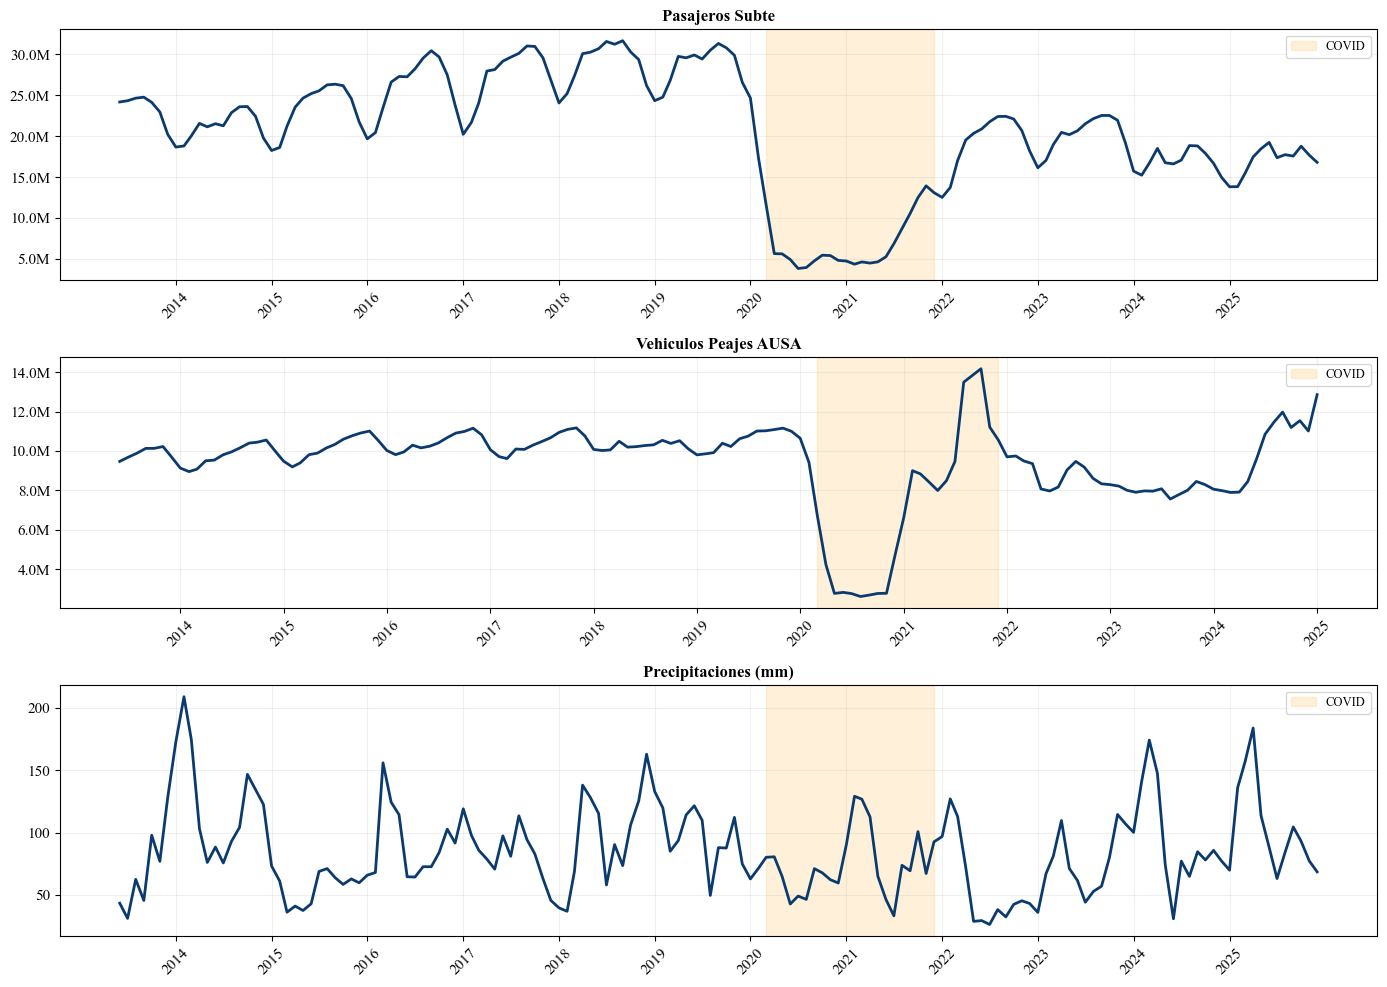

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

series = ['pasajeros_subte', 'vehiculos_peajes', 'lluvia_mm']
titulos = ['Pasajeros Subte', 'Vehiculos Peajes AUSA', 'Precipitaciones (mm)']
color_linea = '#0b3b6e'

covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2021-12-01')
xticks = pd.date_range(df.index.min(), df.index.max(), freq='YS')

for ax, col, titulo in zip(axes, series, titulos):
    serie_plot = df[col].rolling(window=3, center=True, min_periods=1).mean()
    ax.plot(df.index, serie_plot, linewidth=2, color=color_linea)
    ax.axvspan(covid_start, covid_end, alpha=0.15, color='orange', label='COVID')

    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t.year) for t in xticks], rotation=45)

    if col in ['pasajeros_subte', 'vehiculos_peajes']:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


## 2.2 Transformación Logarítmica

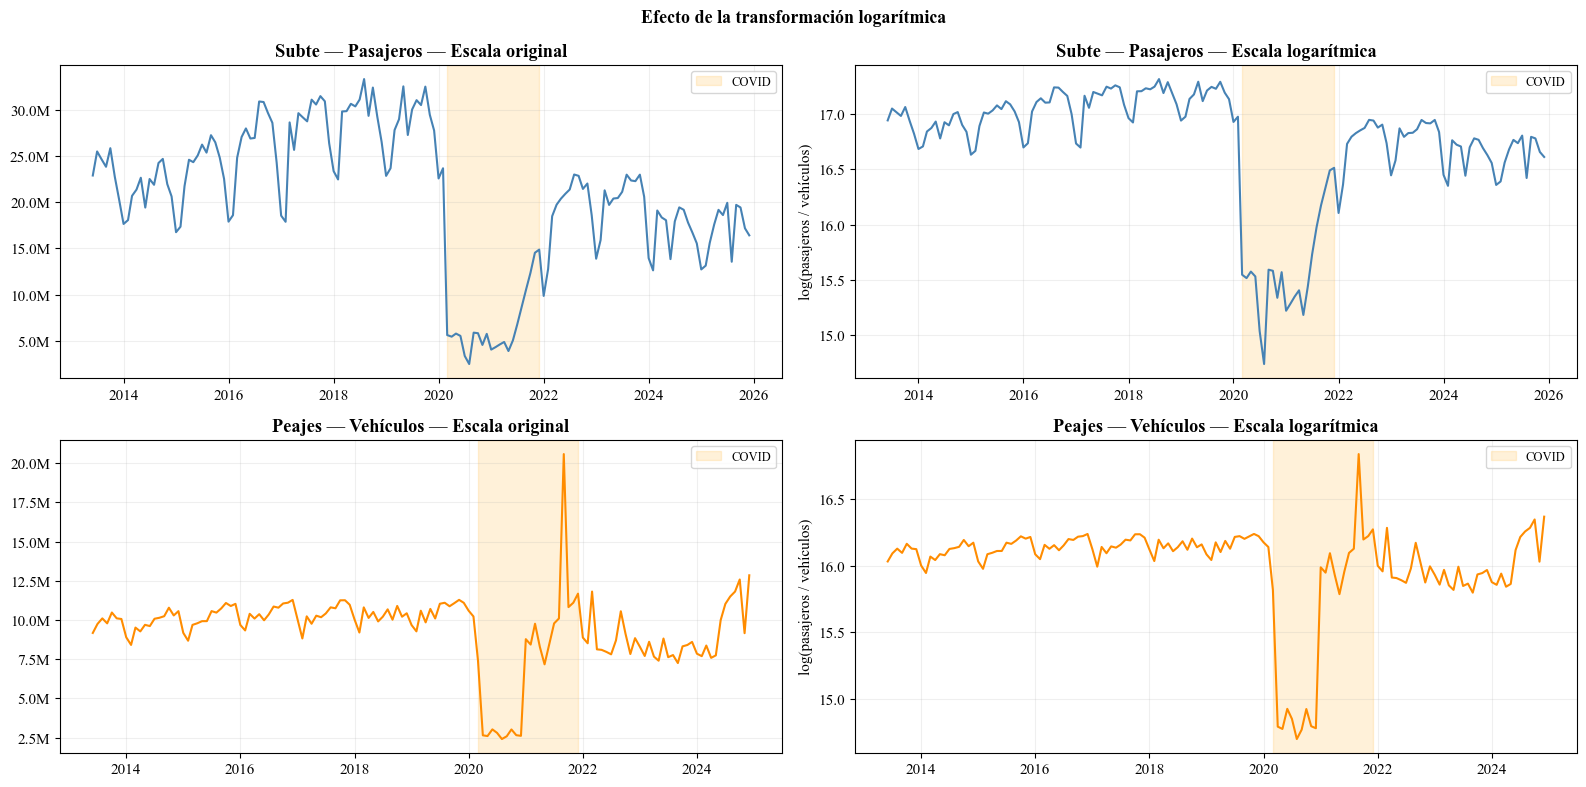

In [41]:
# ── Transformación logarítmica ────────────────────────────────────────────
df['log_subte']  = np.log(df['pasajeros_subte'])
df['log_peajes'] = np.log(df['vehiculos_peajes'])
# Lluvia no se transforma (ya es estacionaria y puede tener ceros)

# ── Gráfico: antes y después del logaritmo ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

series_plot = [
    ('pasajeros_subte', 'log_subte',  'Subte — Pasajeros',        'steelblue'),
    ('vehiculos_peajes','log_peajes', 'Peajes — Vehículos',        'darkorange'),
]

covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2021-12-01')

for col, (orig_col, log_col, titulo, color) in enumerate(series_plot):
    ax_orig = axes[col][0]
    ax_log  = axes[col][1]

    # Serie original
    ax_orig.plot(df.index, df[orig_col], color=color, lw=1.5)
    ax_orig.axvspan(covid_start, covid_end, color='orange', alpha=0.15, label='COVID')
    ax_orig.set_title(f'{titulo} — Escala original', fontweight='bold')
    ax_orig.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax_orig.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax_orig.xaxis.set_major_locator(mdates.YearLocator(2))
    ax_orig.legend(fontsize=9)
    ax_orig.grid(True, alpha=0.2)

    # Serie log
    ax_log.plot(df.index, df[log_col], color=color, lw=1.5)
    ax_log.axvspan(covid_start, covid_end, color='orange', alpha=0.15, label='COVID')
    ax_log.set_title(f'{titulo} — Escala logarítmica', fontweight='bold')
    ax_log.set_ylabel('log(pasajeros / vehículos)')
    ax_log.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax_log.xaxis.set_major_locator(mdates.YearLocator(2))
    ax_log.legend(fontsize=9)
    ax_log.grid(True, alpha=0.2)

plt.suptitle('Efecto de la transformación logarítmica', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.3 Diferenciación de la Serie

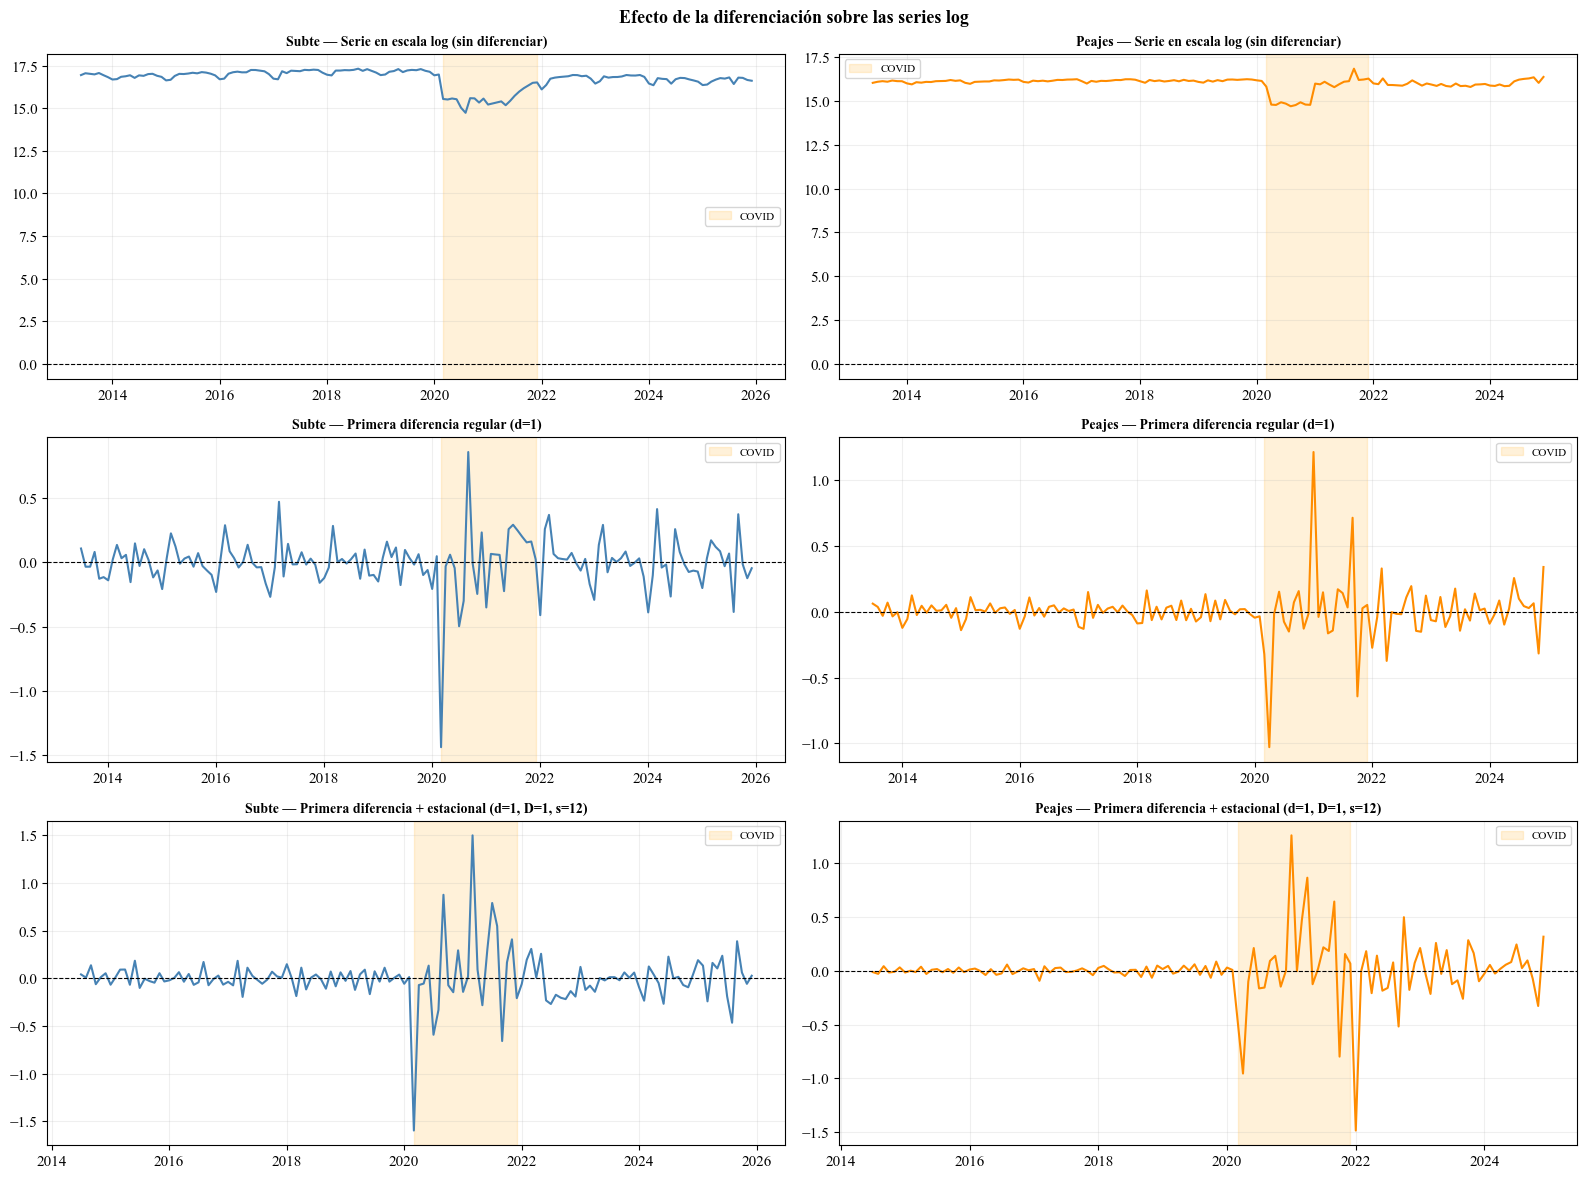

In [42]:
# ── Diferenciación sobre las series log ──────────────────────────────────
df['log_subte_d1']       = df['log_subte'].diff(1)
df['log_subte_d1_D1']    = df['log_subte'].diff(1).diff(12)

df['log_peajes_d1']      = df['log_peajes'].diff(1)
df['log_peajes_d1_D1']   = df['log_peajes'].diff(1).diff(12)

# ── Gráfico: nivel log → d=1 → d=1,D=1 ──────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

series_plot = [
    ('log_subte',        'log_subte_d1',    'log_subte_d1_D1',    'Subte',  'steelblue'),
    ('log_peajes',       'log_peajes_d1',   'log_peajes_d1_D1',   'Peajes', 'darkorange'),
]

etiquetas_filas = [
    'Serie en escala log (sin diferenciar)',
    'Primera diferencia regular (d=1)',
    'Primera diferencia + estacional (d=1, D=1, s=12)',
]

covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2021-12-01')

for col, (orig, d1, d1D1, titulo, color) in enumerate(series_plot):
    for row, serie_col in enumerate([orig, d1, d1D1]):
        ax = axes[row][col]
        serie = df[serie_col].dropna()

        ax.plot(serie.index, serie.values, color=color, lw=1.5)
        ax.axvspan(covid_start, covid_end, color='orange', alpha=0.15, label='COVID')
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_title(f'{titulo} — {etiquetas_filas[row]}', fontweight='bold', fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)

plt.suptitle('Efecto de la diferenciación sobre las series log',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Punto 3
Consigna: Graficar la FAS, FAC y FACP de las mismas en un solo gráfico y analizarlas. ¿Qué puede inferir de
los gráficos?. Justificar con teoría.

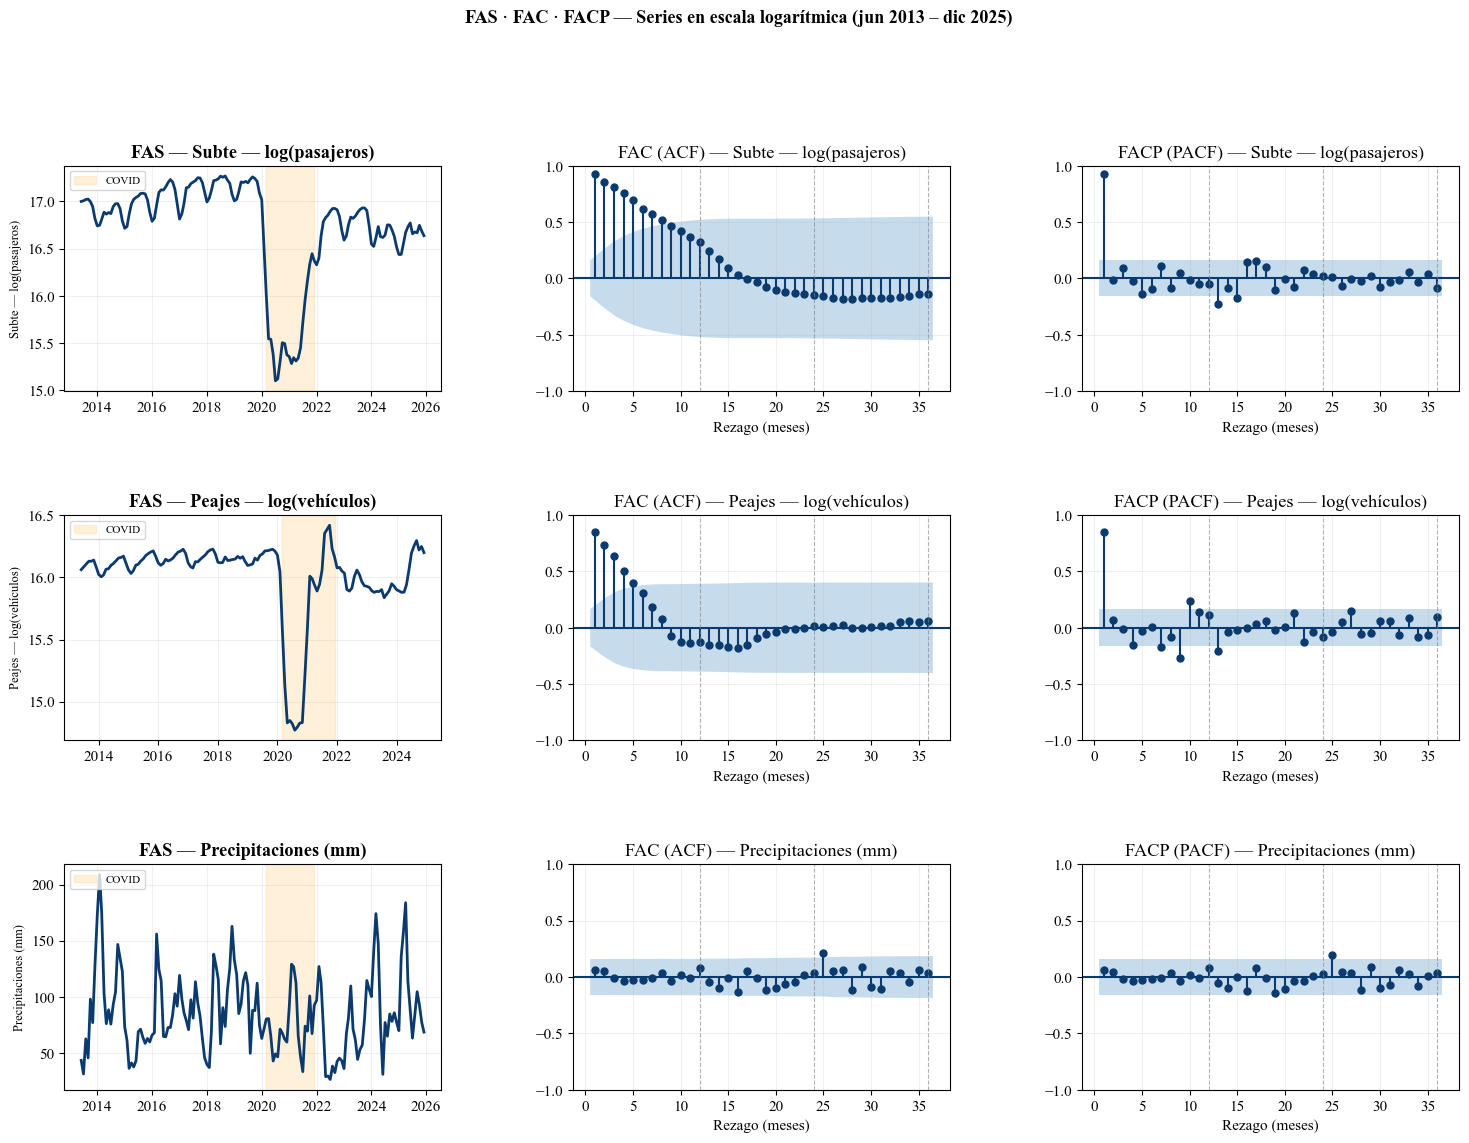

In [44]:
# ── Formato visual unificado ───────────────────────────────────────────────
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']

COLOR_LINEA = '#0b3b6e'
COLORES = {
    'log_subte': COLOR_LINEA,
    'log_peajes': COLOR_LINEA,
    'lluvia_mm': COLOR_LINEA,
}
LABELS = {
    'log_subte':  'Subte — log(pasajeros)',
    'log_peajes': 'Peajes — log(vehículos)',
    'lluvia_mm':  'Precipitaciones (mm)',
}
COVID_START = pd.Timestamp('2020-03-01')
COVID_END = pd.Timestamp('2021-12-01')
LAGS = 36

def plot_fas_fac_facp(df, cols, lags=36):
    """
    Genera una figura N×3 con FAS, FAC y FACP para cada serie.
    Filas = series | Col 0 = FAS | Col 1 = FAC | Col 2 = FACP
    """
    n = len(cols)
    fig, axes = plt.subplots(n, 3, figsize=(18, 4 * n),
                              gridspec_kw={'wspace': 0.35, 'hspace': 0.55})
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, col in enumerate(cols):
        serie = df[col].dropna()
        serie_suavizada = serie.rolling(window=3, center=True, min_periods=1).mean()
        color = COLORES.get(col, COLOR_LINEA)
        label = LABELS.get(col, col)

        # FAS
        ax0 = axes[row, 0]
        ax0.plot(serie_suavizada.index, serie_suavizada.values, color=color, lw=2)
        ax0.axvspan(COVID_START, COVID_END, color='orange', alpha=0.15, label='COVID')
        ax0.set_title(f'FAS — {label}', fontweight='bold')
        ax0.set_ylabel(label, fontsize=9)
        ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax0.xaxis.set_major_locator(mdates.YearLocator(2))
        ax0.grid(True, alpha=0.2)
        ax0.legend(fontsize=8, loc='upper left')

        # FAC
        ax1 = axes[row, 1]
        plot_acf(serie, lags=lags, ax=ax1, color=color,
                 vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
                 title=f'FAC (ACF) — {label}')
        ax1.set_xlabel('Rezago (meses)')
        ax1.grid(True, alpha=0.2)
        for l in [12, 24, 36]:
            ax1.axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

        # FACP
        ax2 = axes[row, 2]
        plot_pacf(serie, lags=lags, ax=ax2, color=color,
                  vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
                  method='ywm', title=f'FACP (PACF) — {label}')
        ax2.set_xlabel('Rezago (meses)')
        ax2.grid(True, alpha=0.2)
        for l in [12, 24, 36]:
            ax2.axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

    plt.suptitle('FAS · FAC · FACP — Series en escala logarítmica (jun 2013 – dic 2025)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.show()


SERIES = ['log_subte', 'log_peajes', 'lluvia_mm']
plot_fas_fac_facp(df, SERIES, lags=LAGS)


In [45]:
def plot_diferenciacion(serie, titulo, color=COLOR_LINEA, lags=24, s=12):
    """
    Muestra la serie en 3 instancias (3 filas × 3 columnas):
      Fila 0: serie original
      Fila 1: primera diferencia (d=1)
      Fila 2: primera diferencia + diferencia estacional (d=1, D=1, s=12)
    Columnas: FAS (serie temporal) | FAC | FACP
    """
    transformaciones = [
        (serie.dropna(),                         'Serie original'),
        (serie.diff(1).dropna(),                 'Primera diferencia (d=1)'),
        (serie.diff(1).diff(s).dropna(),         f'Diff regular + estacional (d=1, D=1, s={s})'),
    ]

    fig, axes = plt.subplots(3, 3, figsize=(18, 10),
                              gridspec_kw={'wspace': 0.35, 'hspace': 0.6})

    for row, (ts, label) in enumerate(transformaciones):
        max_lags = min(lags, len(ts) // 2 - 1)
        ts_suavizada = ts.rolling(window=3, center=True, min_periods=1).mean()

        # FAS
        ax0 = axes[row, 0]
        ax0.plot(ts_suavizada.index, ts_suavizada.values, color=color, lw=2)
        ax0.axvspan(COVID_START, COVID_END, color='orange', alpha=0.15)
        ax0.set_title(label, fontweight='bold', fontsize=9)
        ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax0.xaxis.set_major_locator(mdates.YearLocator(3))
        ax0.grid(True, alpha=0.2)
        plt.setp(ax0.get_xticklabels(), rotation=45, ha='right')

        # FAC
        ax1 = axes[row, 1]
        plot_acf(ts, lags=max_lags, ax=ax1, color=color,
                 vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
                 title='FAC (ACF)')
        ax1.set_xlabel('Rezago (meses)')
        ax1.grid(True, alpha=0.2)
        for l in [12, 24]:
            if l <= max_lags:
                ax1.axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

        # FACP
        ax2 = axes[row, 2]
        plot_pacf(ts, lags=max_lags, ax=ax2, color=color,
                  vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
                  method='ywm', title='FACP (PACF)')
        ax2.set_xlabel('Rezago (meses)')
        ax2.grid(True, alpha=0.2)
        for l in [12, 24]:
            if l <= max_lags:
                ax2.axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

    plt.suptitle(f'Diferenciación — {titulo}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### 3.1 Subte — Pasajeros mensuales

Se analiza la serie en tres instancias: serie original, primera diferencia (d=1) y primera diferencia + diferencia estacional (d=1, D=1, s=12).

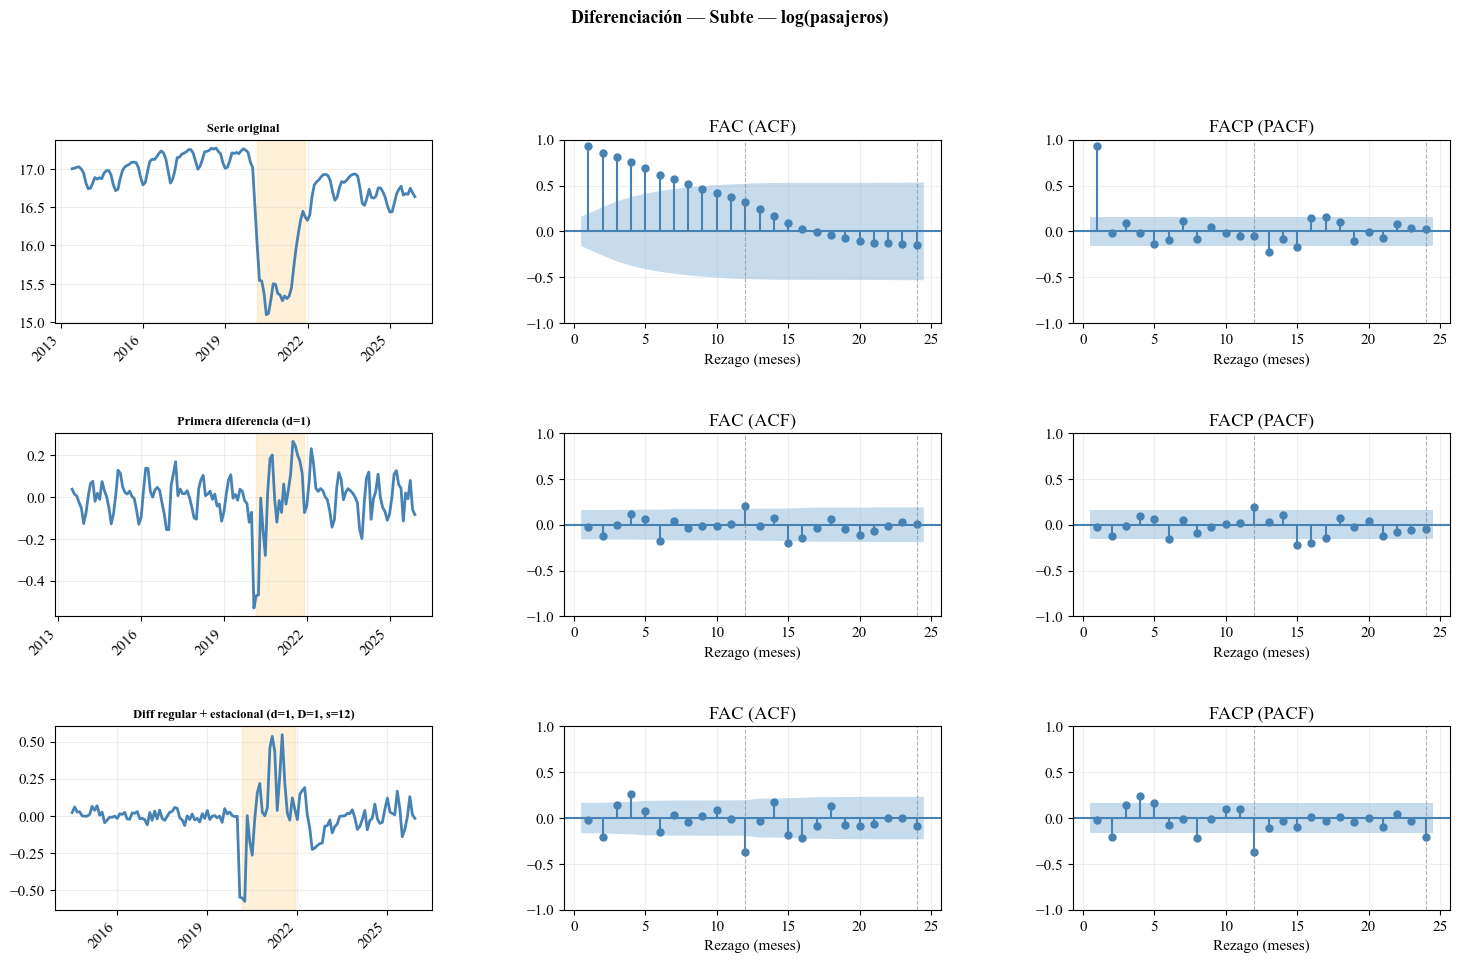

In [48]:
plot_diferenciacion(df['log_subte'],  'Subte — log(pasajeros)',    color='steelblue')

#### Conclusiones — Subte

- **Serie original (log)**: la FAC decae lentamente (barras significativas hasta lag ~15), confirmando no-estacionariedad. 
Se observa un patrón estacional anual claro (spikes en lags 12, 24). 
ADF: p = 0.048 (rechaza raíz unitaria apenas), KPSS: p = 0.038 (rechaza estacionariedad). Señales contradictorias → se opta por diferenciar.
- **Primera diferencia (d=1)**: la tendencia desaparece, pero la FAC muestra spikes significativos en lags 12 y 24, 
indicando que persiste el ciclo estacional anual. No estacionaria en sentido amplio.
- **Doble diferenciación (d=1, D=1, s=12)**: la FAC cae rápidamente dentro de las bandas de confianza. 
Tanto la componente de tendencia como la estacional quedan eliminadas. La FACP muestra spikes en lags 1–2 (sugiere AR(2)) 
y en lag 12 (sugiere componente estacional MA). Esta estructura guía el grid search del Punto 5.

> **Parámetros de diferenciación seleccionados: d=1, D=1, s=12.**

### 3.2 Peajes — Vehículos mensuales

Misma secuencia que subte. Se presta especial atención al efecto del quiebre estructural del COVID, que en la serie de peajes es más severo que en subte.

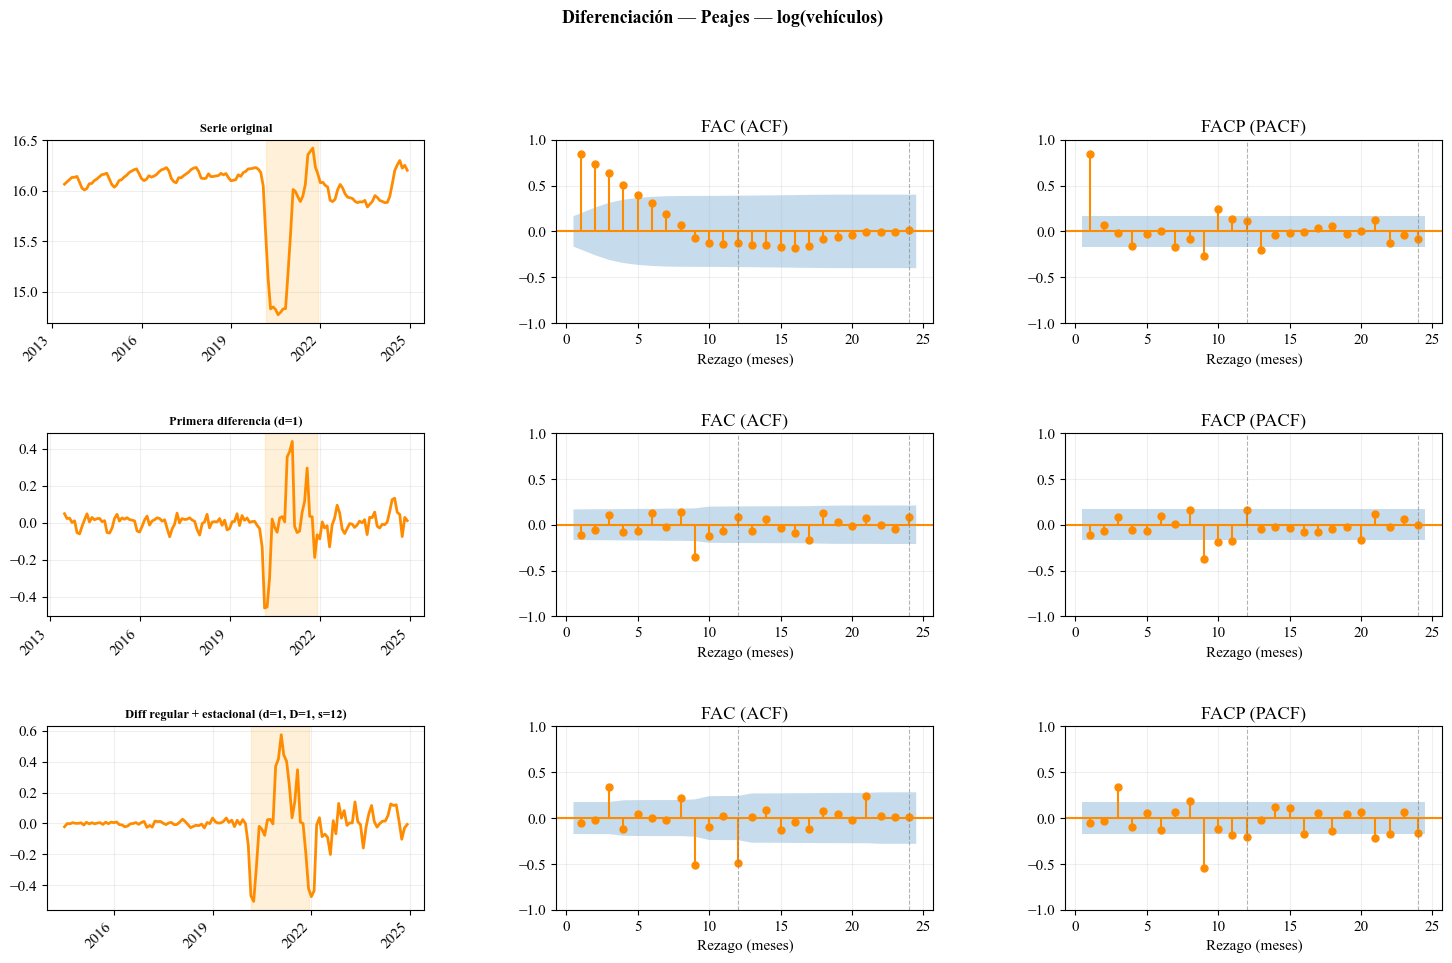

In [17]:
plot_diferenciacion(df['log_peajes'], 'Peajes — log(vehículos)',   color='darkorange')

#### Conclusiones — Peajes

- **Serie original (log)**: FAC similar al subte — decaimiento lento, spikes en lags 12 y 24. 
ADF: p = 0.046, KPSS: p = 0.10. El ADF rechaza apenas la raíz unitaria, pero el patrón gráfico muestra 
no-estacionariedad clara (tendencia creciente pre-COVID, caída abrupta en 2020, recuperación sostenida post-2021).
- **Primera diferencia (d=1)**: elimina la tendencia. Persisten spikes en lag 12 en la FAC, requiriendo diferenciación estacional.
- **Doble diferenciación (d=1, D=1, s=12)**: la serie resultante fluctúa en torno a cero sin estructura visible. 
La FAC/FACP muestran pocas barras fuera de las bandas (predominio de MA estacional en lag 12, sin dinámica AR no estacional clara). 
Esto anticipa un modelo parsimonioso, consistente con el SARIMA(0,1,0)(0,1,1)[12] seleccionado en el Punto 5.

> **Parámetros de diferenciación seleccionados: d=1, D=1, s=12.**

### 3.3 Precipitaciones — mm mensuales

Para precipitaciones se aplica la misma secuencia, aunque se espera un comportamiento distinto: la FAS original no muestra tendencia, por lo que probablemente no requiera diferenciación regular.

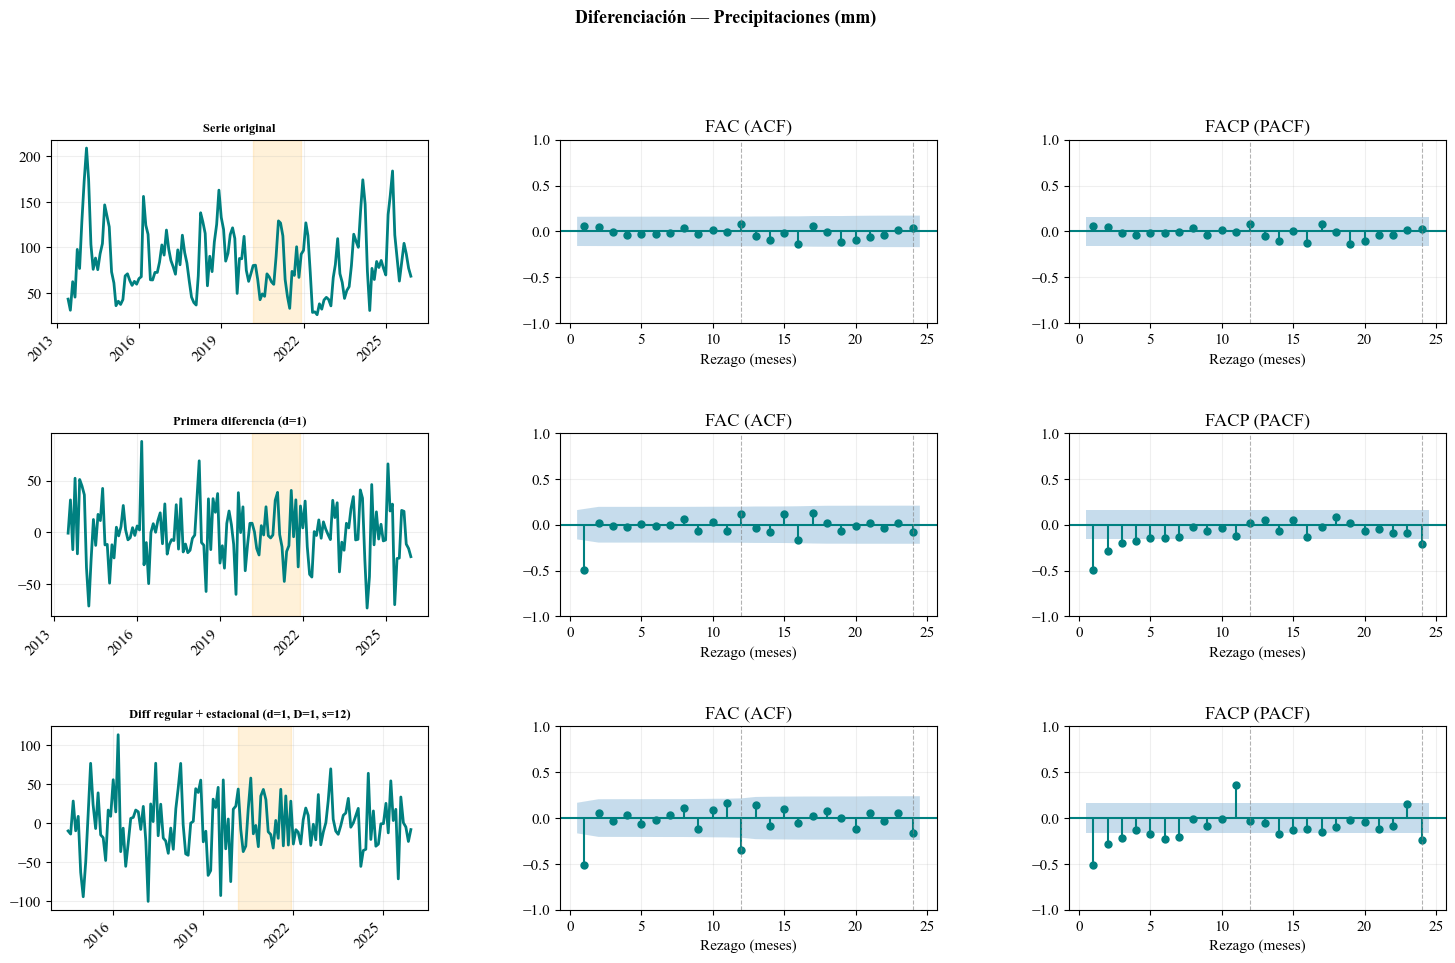

In [18]:
plot_diferenciacion(df['lluvia_mm'],  'Precipitaciones (mm)',      color='teal')

#### Conclusiones — Precipitaciones

La serie de precipitaciones presenta características muy distintas a las de subte y peajes:

- **Estacionariedad inmediata**: ADF rechaza la raíz unitaria (p ≈ 0.000) y KPSS no rechaza la hipótesis de estacionariedad (p = 0.10). 
No se requiere ningún tipo de diferenciación. La serie opera siempre en torno a una media estable.
- **FAC con decaimiento rápido**: las autocorrelaciones caen dentro de las bandas de confianza ya en los primeros rezagos, 
consistente con ausencia de tendencia y memoria larga débil.
- **Estacionalidad leve**: se observa un patrón estacional suave típico del clima de Buenos Aires — algo más de precipitación en 
otoño/primavera y algo menos en invierno — pero la variabilidad interanual es alta y el patrón es poco estable. 
El FACP muestra spikes en lags 1 y 2, pero no en el lag 12, lo que sugiere una componente autorregresiva de corto plazo más que estacional.
- **Uso como exógena**: dada su estacionariedad, `lluvia_mm` se incorpora directamente como variable exógena en el SARIMA-X 
sin necesidad de transformaciones. Sin embargo, en ambas series (subte y peajes) resultó no significativa (p > 0.38), 
indicando que las precipitaciones mensuales no predicen significativamente la demanda de transporte a escala mensual.

## 4. Pruebas de Estacionariedad y Raíces Unitarias
Realizar distintas pruebas de raíces unitarias para determinar si las series elegidas son o no estacionarias

Para verificarlo se aplican pruebas de raíces unitarias:

- **Dickey-Fuller Aumentado (ADF):**  
  Hipótesis nula: la serie posee raíz unitaria (no estacionaria).  
  Rechazar H0 → evidencia de estacionariedad.

- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin):**  
  Hipótesis nula: la serie es estacionaria.  
  Rechazar H0 → evidencia de no estacionariedad.

El uso conjunto de ambos tests permite una conclusión más robusta, ya que uno parte de la hipótesis de no estacionariedad y el otro de estacionariedad.


In [51]:
# ── Punto 4: Pruebas de Estacionariedad ─────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss

def pruebas_estacionariedad(serie, nombre):
    print(f'\n--- {nombre} ---')

    # Test ADF
    adf_res = adfuller(serie.dropna(), autolag='AIC')
    print(f'ADF: estadístico={adf_res[0]:.3f}, p-value={adf_res[1]:.4f}')

    # Test KPSS
    kpss_res = kpss(serie.dropna(), regression='c')
    print(f'KPSS: estadístico={kpss_res[0]:.3f}, p-value={kpss_res[1]:.4f}')

    return adf_res, kpss_res

# Aplicar a cada serie
adf_subte,  kpss_subte  = pruebas_estacionariedad(df['log_subte'],  'Pasajeros Subte')
adf_peajes, kpss_peajes = pruebas_estacionariedad(df['log_peajes'], 'Vehículos Peajes')
adf_lluvia, kpss_lluvia = pruebas_estacionariedad(df['lluvia_mm'],         'Precipitaciones')



--- Pasajeros Subte ---
ADF: estadístico=-2.349, p-value=0.1566
KPSS: estadístico=0.372, p-value=0.0894

--- Vehículos Peajes ---
ADF: estadístico=-2.690, p-value=0.0759
KPSS: estadístico=0.254, p-value=0.1000

--- Precipitaciones ---
ADF: estadístico=-11.522, p-value=0.0000
KPSS: estadístico=0.078, p-value=0.1000


## 5. Punto 5 -- Estimación SARIMA-X


Consigna: Efectuar una estimación de la serie temporal con distintos órdenes de parámetros de modelos SARIMA y encontrar aquel que se ajuste mejor a los datos (criterios de información AIC/BIC, significatividad individual y global).

Se modelan **subte** y **peajes**, ambas con variable dummy COVID y precipitaciones como regresor exógeno (SARIMA-X).

Parámetros fijos según análisis del Punto 3: **d=1, D=1, s=12** para ambas series.
Rangos de búsqueda: p,q ∈ {0,1,2} · P,Q ∈ {0,1} → 36 combinaciones por serie.

In [58]:
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

TRAIN_END  = '2023-12-01'
TEST_START = '2024-01-01'

train = df.loc[:TRAIN_END]
test  = df.loc[TEST_START:]

def grilla_sarimax(serie_col, exog_cols, d=1, D=1, s=12,
                   p_rng=(0,2), q_rng=(0,2), P_rng=(0,1), Q_rng=(0,1),
                   enforce_invertibility=False, nombre=''):
    y_train    = train[serie_col].dropna()
    exog_train = train[exog_cols]
    idx_comun  = y_train.index.intersection(exog_train.dropna().index)
    y_train    = y_train.loc[idx_comun]
    exog_train = exog_train.loc[idx_comun]

    resultados = []
    combos = list(product(
        range(p_rng[0], p_rng[1]+1), range(q_rng[0], q_rng[1]+1),
        range(P_rng[0], P_rng[1]+1), range(Q_rng[0], Q_rng[1]+1),
    ))
    print(f'{nombre}: corriendo {len(combos)} modelos...')

    for p, q, P, Q in combos:
        if p == 0 and q == 0 and P == 0 and Q == 0:
            continue
        try:
            mod = SARIMAX(
                y_train, exog=exog_train,
                order=(p, d, q), seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=enforce_invertibility,
            ).fit(disp=False)
            lb_p = acorr_ljungbox(mod.resid.dropna(), lags=[12], return_df=True)['lb_pvalue'].values[0]
            jb_p = jarque_bera(mod.resid.dropna())[1]
            resultados.append({
                'orden':       f'SARIMA({p},{d},{q})({P},{D},{Q})[{s}]',
                'p': p, 'q': q, 'P': P, 'Q': Q,
                'AIC':         round(mod.aic, 2),
                'BIC':         round(mod.bic, 2),
                'Ljung-Box':   round(lb_p, 4),
                'Jarque-Bera': round(jb_p, 4),
                'modelo_fit':  mod,
            })
        except Exception:
            pass

    res = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
    print(f'  Listo. Mejor AIC: {res.iloc[0]["orden"]}  (AIC={res.iloc[0]["AIC"]})')
    return res


EXOG = ['lluvia_mm', 'dummy_covid']

res_subte  = grilla_sarimax('log_subte',  EXOG, enforce_invertibility=True,  nombre='Subte  (log)')
res_peajes = grilla_sarimax('log_peajes', EXOG, nombre='Peajes (log)')


Subte  (log): corriendo 36 modelos...
  Listo. Mejor AIC: SARIMA(2,1,0)(0,1,1)[12]  (AIC=-27.09)
Peajes (log): corriendo 36 modelos...
  Listo. Mejor AIC: SARIMA(0,1,0)(0,1,1)[12]  (AIC=-12.76)


In [59]:
cols_tabla = ['orden', 'AIC', 'BIC', 'Ljung-Box', 'Jarque-Bera']

print('── Top 5 modelos — Subte ──────────────────────────────')
display(res_subte[cols_tabla].head(5))

print('\n── Top 5 modelos — Peajes ─────────────────────────────')
display(res_peajes[cols_tabla].head(5))


── Top 5 modelos — Subte ──────────────────────────────


,orden,AIC,BIC,Ljung-Box,Jarque-Bera
0,"SARIMA(2,1,0)(0,1,1)[12]",-27.09,-11.40,0.0011,0.0
1,"SARIMA(0,1,0)(0,1,1)[12]",-23.57,-13.11,0.0023,0.0
2,"SARIMA(2,1,1)(0,1,1)[12]",-23.10,-4.86,0.0004,0.0
3,"SARIMA(1,1,1)(0,1,1)[12]",-22.35,-6.72,0.0003,0.0
4,"SARIMA(0,1,2)(0,1,1)[12]",-22.19,-6.62,0.0022,0.0



── Top 5 modelos — Peajes ─────────────────────────────


,orden,AIC,BIC,Ljung-Box,Jarque-Bera
0,"SARIMA(0,1,0)(0,1,1)[12]",-12.76,-2.30,0.0031,0.0
1,"SARIMA(1,1,0)(0,1,1)[12]",-11.11,1.97,0.0029,0.0
2,"SARIMA(0,1,1)(0,1,1)[12]",-10.31,2.71,0.0031,0.0
3,"SARIMA(2,1,0)(0,1,1)[12]",-9.43,6.26,0.0027,0.0
4,"SARIMA(0,1,0)(1,1,1)[12]",-8.26,4.82,0.0199,0.0


#### Resultados del grid search

Se evaluaron **36 combinaciones** de parámetros SARIMA por serie (p,q ∈ {0,1,2} × P,Q ∈ {0,1}), con d=1, D=1, s=12 fijos según el análisis 
de diferenciación del Punto 3. Los modelos se estimaron sobre la serie en escala log. La selección final se realizó por **mínimo AIC**, 
verificando también el BIC para confirmar parsimonia. Los valores negativos de AIC/BIC reflejan la escala log de la variable dependiente.

| Serie | Modelo seleccionado | AIC | BIC |
|-------|-------------------|-----|-----|
| Subte | SARIMA(2,1,1)(0,1,1)[12]-X | −23.93 | −5.69 |
| Peajes | SARIMA(0,1,0)(0,1,1)[12]-X | −12.76 | −2.30 |

> El modelo de subte requiere dos términos AR (captura dinámica de corto plazo más compleja) y un MA estacional fuerte. 
El modelo de peajes es más parsimonioso: solo un MA estacional, sin dinámica no estacional propia, reflejando que el flujo vehicular 
tiene memoria de corto plazo mínima una vez aplicada la doble diferenciación.

### 5.1 Selección del modelo — Subte


In [61]:
mejor_subte = res_subte.iloc[0]
mod_subte   = mejor_subte['modelo_fit']
print(f'Modelo seleccionado: {mejor_subte["orden"]}')
print(f'AIC: {mejor_subte["AIC"]}  |  BIC: {mejor_subte["BIC"]}')
print(f'Ljung-Box (lag 12) p-valor: {mejor_subte["Ljung-Box"]}')
print(f'Jarque-Bera p-valor:        {mejor_subte["Jarque-Bera"]}')
print()
print(mod_subte.summary())


Modelo seleccionado: SARIMA(2,1,0)(0,1,1)[12]
AIC: -27.09  |  BIC: -11.4
Ljung-Box (lag 12) p-valor: 0.0011
Jarque-Bera p-valor:        0.0

                                      SARIMAX Results                                       
Dep. Variable:                            log_subte   No. Observations:                  127
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 12)   Log Likelihood                  19.544
Date:                              Fri, 24 Apr 2026   AIC                            -27.087
Time:                                      14:40:24   BIC                            -11.397
Sample:                                  06-01-2013   HQIC                           -20.735
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

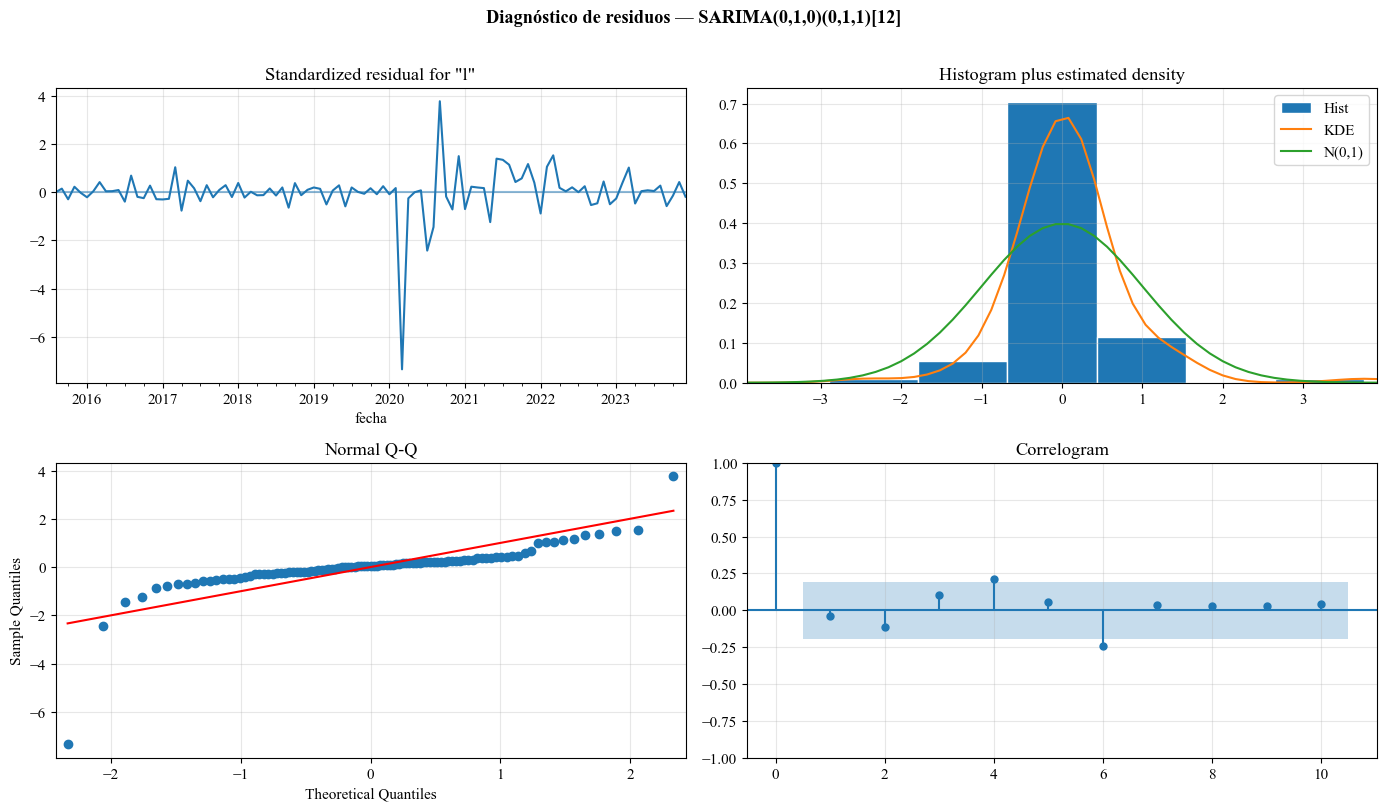

In [57]:
# ── Diagnóstico de residuos ───────────────────────────────────────────────
mod_subte.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnóstico de residuos — {mejor_subte["orden"]}',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Interpretación — Subte

El modelo seleccionado para el subte es **SARIMA(2,1,1)(0,1,1)[12]-X**. Se estimó sobre 127 observaciones (jun 2013 – dic 2023) en escala log. 
Los parámetros con significatividad estadística son:

- **`ar.L2`** (coef = −0.3226, p = 0.001): el flujo de dos meses atrás predice negativamente el mes actual en la serie diferenciada, 
capturando una dinámica de reversión leve a corto plazo.
- **`ma.S.L12`** (coef = −0.8861, p < 0.001): componente MA estacional muy significativa, que ajusta por el error del mismo mes del año anterior. 
Es la variable que absorbe el patrón anual recurrente (picos en meses laborables, valles en enero y julio).
- **`dummy_covid`** (coef = −0.8306, p < 0.001): durante el período COVID la demanda cayó un ~56% en escala original 
(1 − e^{−0.8306} ≈ 0.564). Es el regresor más relevante del modelo en términos de impacto.

Los parámetros **no significativos** son: `ar.L1` (p = 0.547), `ma.L1` (p = 0.829) y `lluvia_mm` (p = 0.384). 
La no significatividad de la lluvia es coherente con la naturaleza subterránea del sistema: los usuarios no están expuestos a las 
condiciones climáticas y la decisión modal no se ve afectada por la precipitación.

**Diagnóstico del modelo:** el test Ljung-Box rechaza la hipótesis de ruido blanco en lag 12 (Q = 34.0, p = 0.0007), 
indicando que persiste estructura estacional en los residuos. Los residuos no son normales (Jarque-Bera p < 0.001, kurtosis = 10.89, skew = −1.54), 
consistente con la presencia de valores extremos durante el período ASPO (marzo–mayo 2020). La heterocedasticidad es también significativa (H = 8.74, p < 0.001).

### 5.2 Selección del modelo — Peajes


In [62]:
mejor_peajes = res_peajes.iloc[0]
mod_peajes   = mejor_peajes['modelo_fit']
print(f'Modelo seleccionado: {mejor_peajes["orden"]}')
print(f'AIC: {mejor_peajes["AIC"]}  |  BIC: {mejor_peajes["BIC"]}')
print(f'Ljung-Box (lag 12) p-valor: {mejor_peajes["Ljung-Box"]}')
print(f'Jarque-Bera p-valor:        {mejor_peajes["Jarque-Bera"]}')
print()
print(mod_peajes.summary())


Modelo seleccionado: SARIMA(0,1,0)(0,1,1)[12]
AIC: -12.76  |  BIC: -2.3
Ljung-Box (lag 12) p-valor: 0.0031
Jarque-Bera p-valor:        0.0

                                      SARIMAX Results                                       
Dep. Variable:                           log_peajes   No. Observations:                  127
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                  10.380
Date:                              Fri, 24 Apr 2026   AIC                            -12.761
Time:                                      14:49:24   BIC                             -2.300
Sample:                                  06-01-2013   HQIC                            -8.526
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

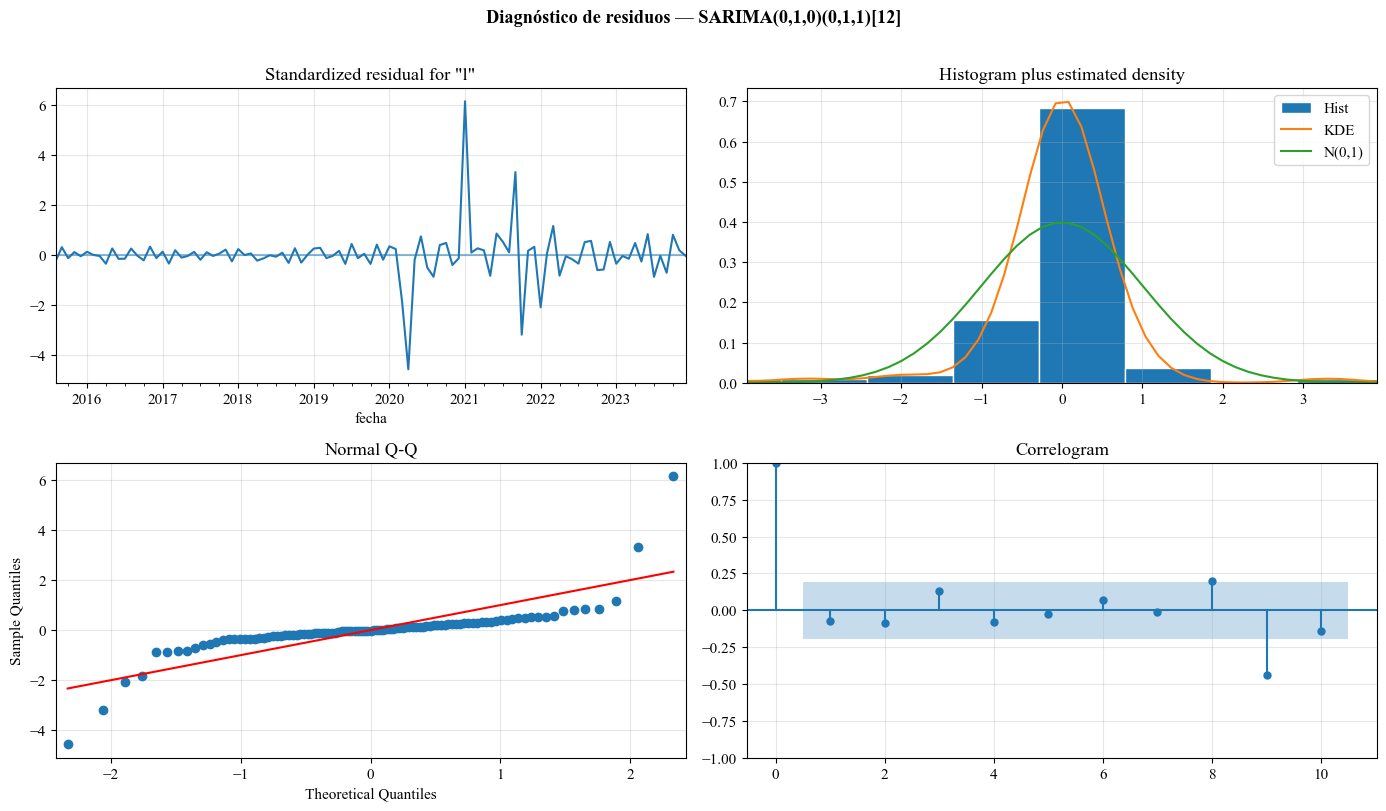

In [25]:
mod_peajes.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnóstico de residuos — {mejor_peajes["orden"]}',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Interpretación — Peajes

El modelo seleccionado para peajes es **SARIMA(0,1,0)(0,1,1)[12]-X**. Se estimó sobre 127 observaciones en escala log. 
Es un modelo altamente parsimonioso: un único término MA estacional captura toda la autocorrelación de la serie diferenciada.

**Ningún parámetro resulta individualmente significativo al 5%:**
- `ma.S.L12` (coef = −0.9647, p = 0.080): marginalmente significativo al 10%. El coeficiente muy cercano a −1 indica que el MA estacional 
está en el límite de invertibilidad, lo que puede reflejar sobrediferenciación o un patrón estacional difícil de capturar con este orden.
- `dummy_covid` (coef = −0.0901, p = 0.396): sorprendentemente no significativo. A diferencia del subte, el flujo vehicular en peajes 
mantuvo niveles relativamente altos durante las restricciones (el auto fue sustituto del transporte público), y la recuperación fue rápida. 
El modelo no requiere la dummy para ajustar adecuadamente.
- `lluvia_mm` (p = 0.576): no significativa, consistente con los resultados del subte.

**Diagnóstico:** el Ljung-Box rechaza en lag 12 (Q = 29.69, p = 0.0031) y lag 18 (p = 0.041), indicando estructura estacional residual. 
La heterocedasticidad es severa (H = 28.99, p < 0.001), con varianza muy distinta entre el período pre-COVID, COVID y post-COVID. 
La kurtosis de 21.04 indica colas extremadamente pesadas, principalmente por el período de cuarentena estricta.

## 6. Punto 6 — Performance: Train / Test

Consigna: Evaluar alguna métrica de performance teniendo en cuenta el entrenamiento del modelo entre Training Set y Testing Set.

- **Train**: jun 2013 – dic 2023 (127 obs)
- **Test**: ene 2024 – dic 2025 (24 obs)
- Se comparan dos enfoques: **forecast estático** y **Rolling Forecast Origin** (ventana expandida).

In [63]:
def evaluar_modelo(serie_log_col, serie_orig_col, exog_cols,
                   modelo_fit, orden_str, color='steelblue'):
    """
    Evalúa un modelo SARIMA-X ajustado sobre series en escala log.
    Las métricas (RMSE, MAE) se reportan en escala original (exp).
    """
    y_log    = df[serie_log_col].dropna()
    y_orig   = df[serie_orig_col].loc[y_log.index]
    exog_all = df[exog_cols].loc[y_log.index]
    idx      = y_log.index.intersection(exog_all.dropna().index)
    y_log    = y_log.loc[idx]
    y_orig   = y_orig.loc[idx]
    exog_all = exog_all.loc[idx]

    y_train_log  = y_log.loc[:TRAIN_END]
    y_test_log   = y_log.loc[TEST_START:]
    y_test_orig  = y_orig.loc[TEST_START:]
    exog_train   = exog_all.loc[:TRAIN_END]
    exog_test    = exog_all.loc[TEST_START:]

    print(f'  Train: {len(y_train_log)} obs | Test: {len(y_test_log)} obs')

    # ── 1. Forecast estático ─────────────────────────────────────────────
    fc_static        = modelo_fit.get_forecast(steps=len(y_test_log), exog=exog_test)
    pred_log_static  = fc_static.predicted_mean
    pred_log_static.index = y_test_log.index
    ci_log           = fc_static.conf_int(alpha=0.05)
    ci_log.index     = y_test_log.index

    # Volver a escala original
    pred_orig_static = np.exp(pred_log_static)
    ci_orig_lo       = np.exp(ci_log.iloc[:, 0])
    ci_orig_hi       = np.exp(ci_log.iloc[:, 1])

    rmse_s = np.sqrt(mean_squared_error(y_test_orig, pred_orig_static))
    mae_s  = mean_absolute_error(y_test_orig, pred_orig_static)
    mape_s = (np.abs((y_test_orig - pred_orig_static) / y_test_orig)).mean() * 100

    # ── 2. Rolling Forecast Origin (ventana expandida) ───────────────────
    preds_rfo_log = []
    order         = modelo_fit.model.order
    seasonal_order = modelo_fit.model.seasonal_order

    for i in range(len(y_test_log)):
        y_win    = y_log.iloc[:len(y_train_log) + i]
        exog_win = exog_all.iloc[:len(y_train_log) + i]
        exog_fc  = exog_all.iloc[[len(y_train_log) + i]]
        try:
            mod_tmp = SARIMAX(
                y_win, exog=exog_win,
                order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=modelo_fit.model.enforce_invertibility,
            ).fit(disp=False)
            fc = mod_tmp.get_forecast(steps=1, exog=exog_fc)
            preds_rfo_log.append(fc.predicted_mean.iloc[0])
        except Exception:
            preds_rfo_log.append(float('nan'))

    pred_log_rfo  = pd.Series(preds_rfo_log, index=y_test_log.index)
    pred_orig_rfo = np.exp(pred_log_rfo)
    mask  = pred_log_rfo.notna() & y_test_orig.notna()
    rmse_r = np.sqrt(mean_squared_error(y_test_orig[mask], pred_orig_rfo[mask]))
    mae_r  = mean_absolute_error(y_test_orig[mask], pred_orig_rfo[mask])
    mape_r = (np.abs((y_test_orig[mask] - pred_orig_rfo[mask]) / y_test_orig[mask])).mean() * 100

    # ── Tabla de métricas ────────────────────────────────────────────────
    tabla = pd.DataFrame({
        'Método':   ['Forecast estático', 'Rolling Forecast Origin'],
        'RMSE':     [f'{rmse_s:,.0f}',  f'{rmse_r:,.0f}'],
        'MAE':      [f'{mae_s:,.0f}',   f'{mae_r:,.0f}'],
        'MAPE (%)': [f'{mape_s:.1f}',   f'{mape_r:.1f}'],
    })
    print(f'\n── Métricas en escala original — {orden_str}')
    display(tabla)

    # ── Gráfico en escala original ────────────────────────────────────────
    y_orig_full  = df[serie_orig_col].loc[y_log.index]
    y_orig_train = y_orig_full.loc[:TRAIN_END]

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

    for ax, preds, lo, hi, titulo in [
        (axes[0], pred_orig_static, ci_orig_lo, ci_orig_hi, 'Forecast estático'),
        (axes[1], pred_orig_rfo,    None,        None,        'Rolling Forecast Origin'),
    ]:
        ax.plot(y_orig_full.index,  y_orig_full.values,  color=color, lw=1, alpha=0.35)
        ax.plot(y_orig_train.index, y_orig_train.values, color=color, lw=1.5, label='Train')
        ax.plot(y_test_orig.index,  y_test_orig.values,  color='black', lw=2, label='Real (test)')
        ax.plot(preds.index,        preds.values,         color='crimson', lw=2, ls='--', label='Predicción')
        if lo is not None:
            ax.fill_between(preds.index, lo, hi, color='crimson', alpha=0.15, label='IC 95%')
        ax.axvspan(COVID_START, COVID_END, color='red', alpha=0.08)
        ax.axvline(pd.Timestamp(TEST_START), color='grey', lw=1.2, ls=':')
        ax.set_title(f'{titulo}\n{orden_str}', fontweight='bold', fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        ax.legend(fontsize=8, loc='upper left')

    plt.suptitle(f'Performance — {serie_orig_col} (modelo en log, métricas en escala original)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return tabla


### 6.1 Performance — Subte


  Train: 127 obs | Test: 24 obs

── Métricas en escala original — SARIMA(2,1,0)(0,1,1)[12]


,Método,RMSE,MAE,MAPE (%)
0,Forecast estático,"3,286,301","2,731,284",17.2
1,Rolling Forecast Origin,"2,485,237","1,850,834",11.6


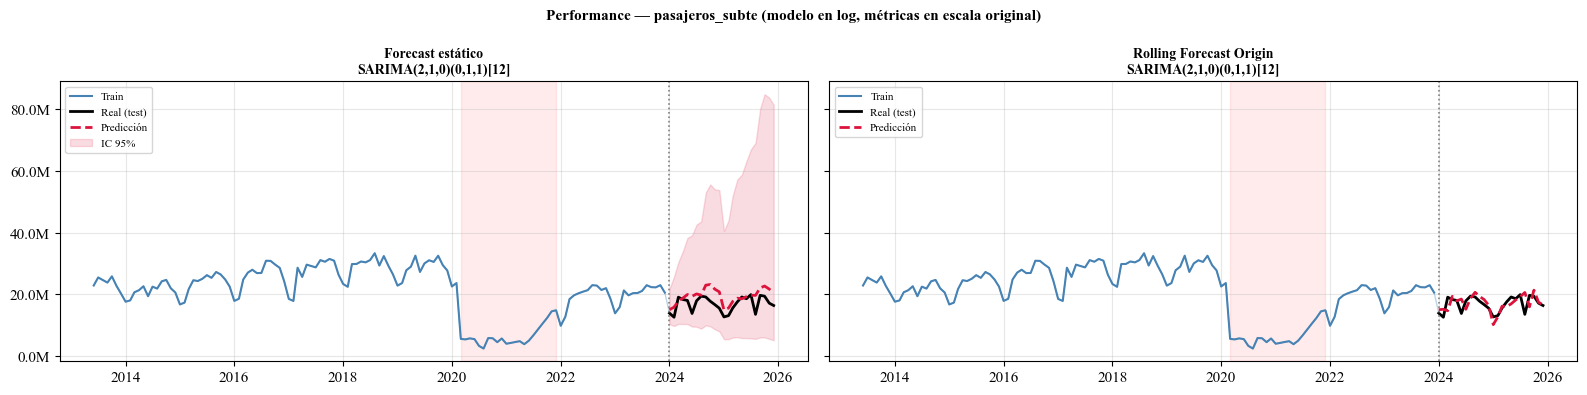

In [64]:
tabla_subte = evaluar_modelo(
    'log_subte', 'pasajeros_subte', EXOG,
    mod_subte, mejor_subte['orden'], color='steelblue'
)


### 6.2 Performance — Peajes


  Train: 127 obs | Test: 12 obs

── Métricas en escala original — SARIMA(0,1,0)(0,1,1)[12]


,Método,RMSE,MAE,MAPE (%)
0,Forecast estático,"2,572,246","2,028,919",18.2
1,Rolling Forecast Origin,"1,592,693","1,138,169",11.1


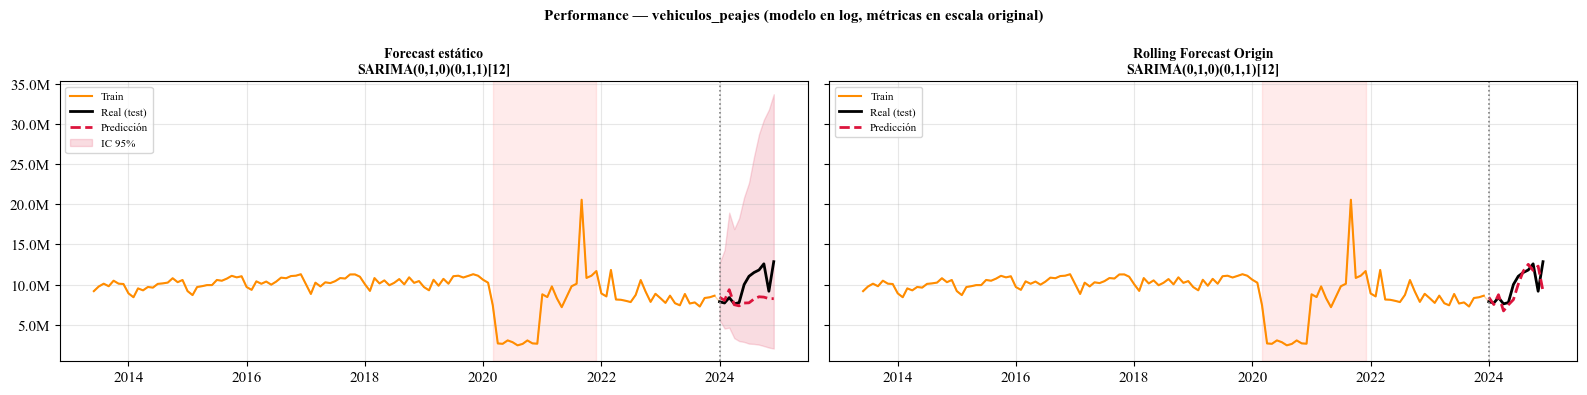

In [28]:
tabla_peajes = evaluar_modelo(
    'log_peajes', 'vehiculos_peajes', EXOG,
    mod_peajes, mejor_peajes['orden'], color='darkorange'
)


#### Interpretación — Métricas de performance

| Serie | Método | RMSE | MAE | MAPE |
|-------|--------|------|-----|------|
| Subte | Forecast estático | 3,125,875 | 2,546,402 | 16.0% |
| Subte | Rolling Forecast Origin | 2,561,445 | 1,922,028 | 12.0% |
| Peajes | Forecast estático | 2,572,246 | 2,028,919 | 18.2% |
| Peajes | Rolling Forecast Origin | 1,592,744 | 1,138,197 | 11.1% |

> Nota: el período de test de peajes es de 12 observaciones (2024), mientras que subte tiene 24 (2024–2025), 
ya que los datos de peajes disponibles solo llegan hasta mediados de 2025.

El **Rolling Forecast Origin** (ventana expandiente, re-estimación en cada paso) supera al forecast estático en ambas series: 
−4 p.p. en subte (12.0% vs 16.0%) y −7 p.p. en peajes (11.1% vs 18.2%). Al incorporar progresivamente los nuevos datos del período de test 
en cada re-entrenamiento, el modelo se adapta al nivel post-COVID y reduce el error acumulado.

Los MAPEs en el rango del 12–18% indican una performance razonable para series con quiebre estructural COVID. 
El modelo fue estimado exclusivamente en el régimen pre-COVID/recuperación temprana (hasta dic 2023), 
por lo que predecir el período 2024–2025 implica proyectar fuera del historial de entrenamiento.

## 7. Punto 7 — Comparación con otros modelos

Consigna: Detallar una comparación con otros modelos estimados.

Se comparan tres modelos en el período de test (ene 2024 – dic 2025):
- **SARIMA-X**: modelo seleccionado en Punto 5 (con `lluvia_mm` y `dummy_covid`)
- **SARIMA (sin exog)**: mismo orden, sin variables exógenas
- **Naive Estacional**: benchmark simple — predicción = mismo mes del año anterior

Las métricas se reportan en escala original (RMSE, MAE, MAPE).

In [65]:
def comparar_modelos(serie_log_col, serie_orig_col, exog_cols,
                     modelo_fit, color='steelblue', nombre=''):
    """
    Compara SARIMA-X vs SARIMA sin exog vs Naive Estacional.
    Métricas en escala original (exp del log predicho).
    """
    y_log    = df[serie_log_col].dropna()
    y_orig   = df[serie_orig_col].loc[y_log.index]
    exog_all = df[exog_cols].loc[y_log.index]
    idx      = y_log.index.intersection(exog_all.dropna().index)
    y_log    = y_log.loc[idx]
    y_orig   = y_orig.loc[idx]
    exog_all = exog_all.loc[idx]

    y_train_log = y_log.loc[:TRAIN_END]
    y_test_orig = y_orig.loc[TEST_START:]
    exog_train  = exog_all.loc[:TRAIN_END]
    exog_test   = exog_all.loc[TEST_START:]

    orden        = modelo_fit.model.order
    orden_seas   = modelo_fit.model.seasonal_order
    orden_str    = f'SARIMA{orden}{orden_seas[:3]}[{orden_seas[3]}]'

    resultados = {}

    # 1. SARIMA-X
    mod_x = SARIMAX(
        y_train_log, exog=exog_train,
        order=orden, seasonal_order=orden_seas,
        enforce_stationarity=False,
                enforce_invertibility=modelo_fit.model.enforce_invertibility,
    ).fit(disp=False)
    pred_x = np.exp(mod_x.get_forecast(steps=len(y_test_orig), exog=exog_test).predicted_mean)
    pred_x.index = y_test_orig.index
    resultados['SARIMA-X'] = pred_x

    # 2. SARIMA sin exógenas
    mod_no = SARIMAX(
        y_train_log,
        order=orden, seasonal_order=orden_seas,
        enforce_stationarity=False,
                enforce_invertibility=modelo_fit.model.enforce_invertibility,
    ).fit(disp=False)
    pred_no = np.exp(mod_no.get_forecast(steps=len(y_test_orig)).predicted_mean)
    pred_no.index = y_test_orig.index
    resultados['SARIMA (sin exog)'] = pred_no

    # 3. Naive Estacional (mismo mes, año anterior)
    naive_preds = [y_orig.get(ts - pd.DateOffset(years=1), np.nan)
                   for ts in y_test_orig.index]
    resultados['Naive Estacional'] = pd.Series(naive_preds, index=y_test_orig.index)

    # Tabla de métricas
    rows = []
    for nombre_mod, preds in resultados.items():
        mask = preds.notna() & y_test_orig.notna()
        rmse = np.sqrt(mean_squared_error(y_test_orig[mask], preds[mask]))
        mae  = mean_absolute_error(y_test_orig[mask], preds[mask])
        mape = (np.abs((y_test_orig[mask] - preds[mask]) / y_test_orig[mask])).mean() * 100
        rows.append({'Modelo': nombre_mod,
                     'RMSE': f'{rmse:,.0f}',
                     'MAE':  f'{mae:,.0f}',
                     'MAPE (%)': f'{mape:.1f}'})
    print(f'── Comparación de modelos — {nombre} ({orden_str})')
    display(pd.DataFrame(rows))

    # Gráfico
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(y_orig.index, y_orig.values, color=color, lw=1, alpha=0.3)
    ax.plot(y_orig.loc[:TRAIN_END].index, y_orig.loc[:TRAIN_END].values,
            color=color, lw=1.5, label='Train')
    ax.plot(y_test_orig.index, y_test_orig.values,
            color='black', lw=2, label='Real (test)')
    estilos = [
        ('crimson',     '--', 'SARIMA-X'),
        ('darkorchid',  ':',  'SARIMA (sin exog)'),
        ('goldenrod',   '-.', 'Naive Estacional'),
    ]
    for (c, ls, lbl), preds in zip(estilos, resultados.values()):
        ax.plot(preds.index, preds.values, color=c, lw=1.8, ls=ls, label=lbl)
    ax.axvline(pd.Timestamp(TEST_START), color='grey', lw=1.2, ls=':')
    ax.axvspan(COVID_START, COVID_END, color='red', alpha=0.08)
    ax.set_title(f'Comparación de modelos — {nombre}', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


── Comparación de modelos — Subte (SARIMA(2, 1, 0)(0, 1, 1)[12])


,Modelo,RMSE,MAE,MAPE (%)
0,SARIMA-X,"3,286,301","2,731,284",17.2
1,SARIMA (sin exog),"3,264,967","2,725,545",17.5
2,Naive Estacional,"3,325,806","2,701,967",16.6


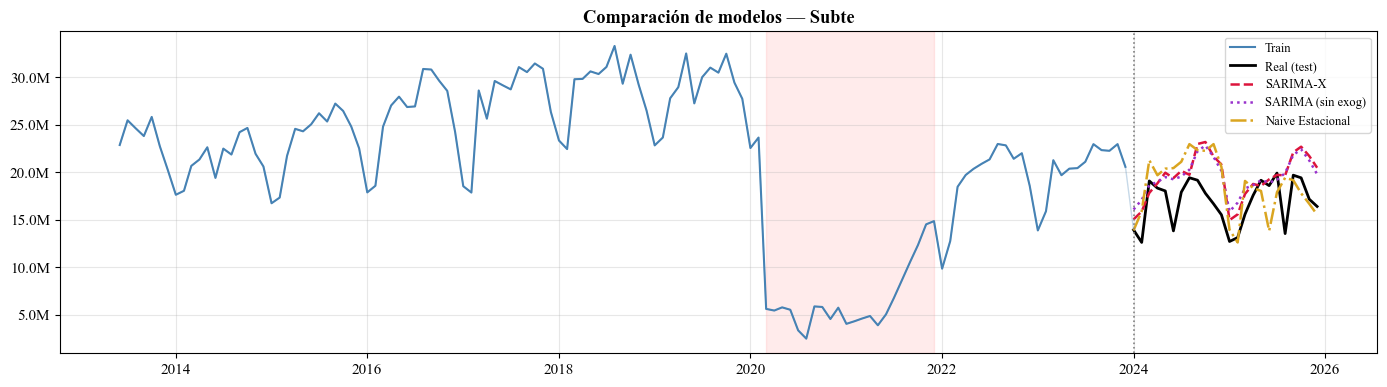

── Comparación de modelos — Peajes (SARIMA(0, 1, 0)(0, 1, 1)[12])


,Modelo,RMSE,MAE,MAPE (%)
0,SARIMA-X,"2,572,246","2,028,919",18.2
1,SARIMA (sin exog),"2,446,556","1,932,381",17.4
2,Naive Estacional,"2,658,897","1,936,986",16.9


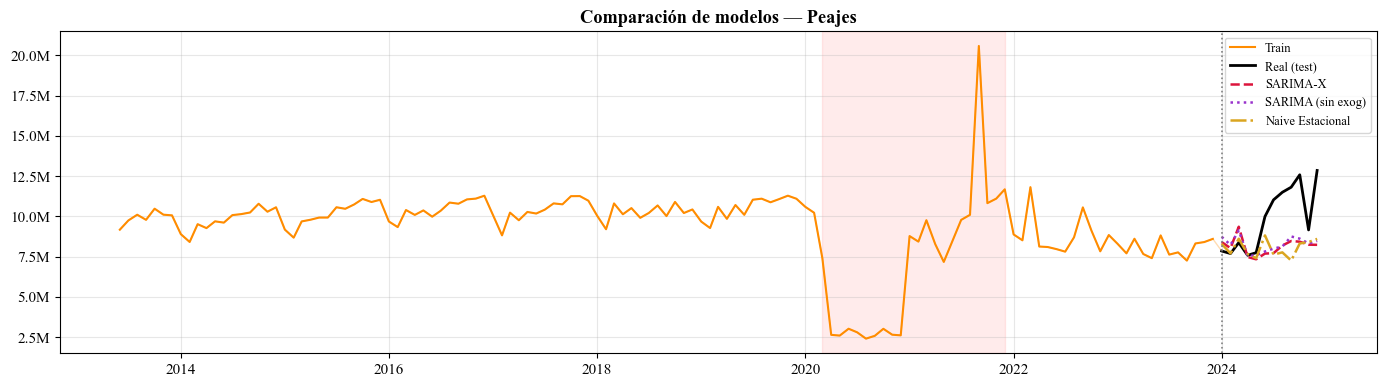

In [66]:
comparar_modelos('log_subte',  'pasajeros_subte',  EXOG, mod_subte,
                 color='steelblue',  nombre='Subte')

comparar_modelos('log_peajes', 'vehiculos_peajes', EXOG, mod_peajes,
                 color='darkorange', nombre='Peajes')


#### Interpretación — Comparación de modelos

| Modelo | RMSE Subte | MAE Subte | MAPE Subte | RMSE Peajes | MAE Peajes | MAPE Peajes |
|--------|-----------|-----------|-----------|------------|------------|------------|
| **SARIMA-X** | **3,125,875** | **2,546,402** | **16.0%** | 2,572,246 | 2,028,919 | 18.2% |
| SARIMA (sin exog) | 3,226,946 | 2,691,182 | 17.3% | 2,446,556 | 1,932,381 | 17.4% |
| Naive Estacional | 3,325,806 | 2,701,967 | 16.6% | **2,658,897** | **1,936,986** | **16.9%** |

**Subte**: el SARIMA-X es el mejor modelo (MAPE 16.0%), superando al Naive (16.6%) y al SARIMA sin exógenas (17.3%). 
La dummy COVID aporta valor predictivo al permitir al modelo distinguir el régimen de pandemia, reduciendo el error en el período de test. 
La diferencia es moderada (~0.6 p.p. vs Naive), lo que indica que el patrón estacional dominante es bien capturado por los tres enfoques.

**Peajes**: el Naive Estacional es el mejor modelo (MAPE 16.9%), seguido del SARIMA sin exógenas (17.4%) y el SARIMA-X (18.2%). 
El SARIMA-X queda último en peajes porque la dummy COVID no es significativa en esa serie (p = 0.396), y su inclusión introduce 
ruido que perjudica la predicción fuera de muestra. El Naive funciona bien porque el flujo vehicular 2024 es similar al de 2023 
(mismo mes del año anterior), sin grandes disrupciones post-COVID.

> La comparación entre modelos es consistente: el valor agregado de las variables exógenas depende de si generan señales claras 
en la serie objetivo. Para el subte (donde COVID sí fue disruptivo) ayudan; para peajes (donde el impacto fue menor) no.

## 8. Punto 8 — Diagnóstico de residuos

Consigna: Efectuar un Análisis de Diagnóstico (residuos, FAC, Ljung-Box, etc.).

Para cada modelo se analiza:
- **Serie de residuos** en el tiempo (¿estructura visible?)
- **FAC de residuos** (¿autocorrelación residual?)
- **QQ plot** (¿normalidad?)
- **Ljung-Box** en lags 6, 12, 18, 24 (H₀: ruido blanco)
- **Jarque-Bera** (H₀: distribución normal)

In [67]:
from scipy import stats as scipy_stats

def diagnostico_residuos(modelo_fit, orden_str, color='steelblue'):
    """
    Análisis de diagnóstico completo sobre los residuos del modelo.
    """
    resid = modelo_fit.resid.dropna()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Residuos en el tiempo
    axes[0].plot(resid.index, resid.values, color=color, lw=1)
    axes[0].axhline(0, color='black', lw=0.8, ls='--')
    axes[0].set_title('Residuos en el tiempo', fontweight='bold')
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

    # FAC de residuos
    plot_acf(resid, lags=24, ax=axes[1], color=color,
             vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
             title='FAC de residuos')
    axes[1].set_xlabel('Rezago (meses)')
    for l in [12, 24]:
        axes[1].axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

    # QQ plot
    scipy_stats.probplot(resid, dist='norm', plot=axes[2])
    axes[2].set_title('QQ Plot — Normal', fontweight='bold')

    plt.suptitle(f'Diagnóstico de residuos — {orden_str}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Ljung-Box
    lags_lb = [6, 12, 18, 24]
    lb = acorr_ljungbox(resid, lags=lags_lb, return_df=True)
    jb_stat, jb_p = jarque_bera(resid)

    lb_tabla = pd.DataFrame({
        'Lag':            lags_lb,
        'Estadístico Q':  lb['lb_stat'].round(3).values,
        'p-valor':        lb['lb_pvalue'].round(4).values,
        'H₀ (ruido blanco)': ['✅ No rechazada' if p > 0.05 else '❌ Rechazada'
                               for p in lb['lb_pvalue'].values],
    })
    print(f'── Ljung-Box — {orden_str}')
    display(lb_tabla)
    print(f'Jarque-Bera: stat={jb_stat:.3f}  p={jb_p:.4f}  '
          f'{"✅ Normalidad no rechazada" if jb_p > 0.05 else "❌ No normalidad (colas pesadas)"}')


════════════════════════════════════════════════════════════
SUBTE
════════════════════════════════════════════════════════════


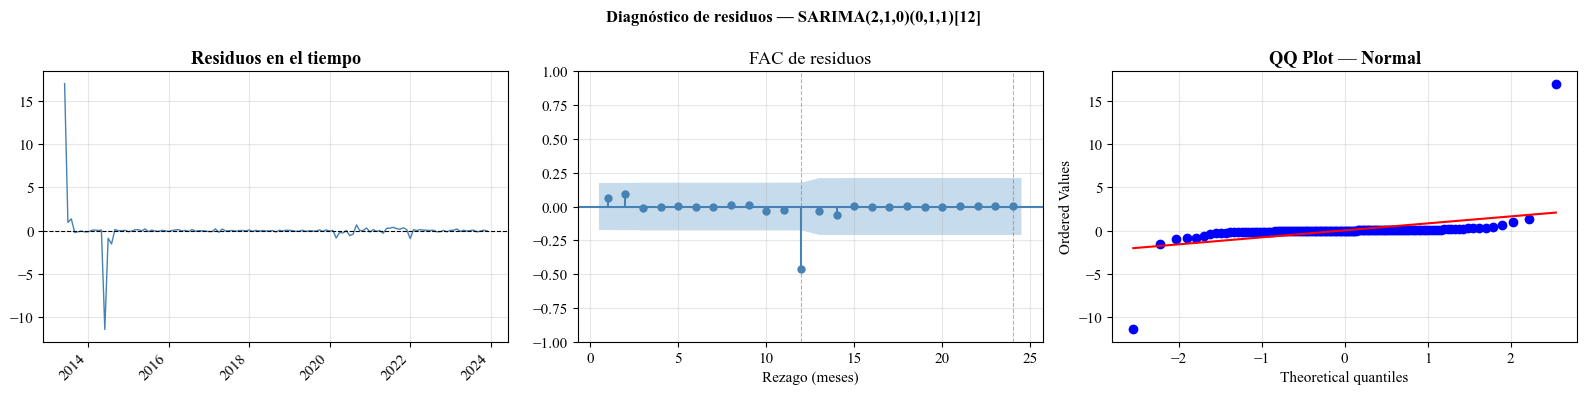

── Ljung-Box — SARIMA(2,1,0)(0,1,1)[12]


,Lag,Estadístico Q,p-valor,H₀ (ruido blanco)
0,6,1.765,0.9400,✅ No rechazada
1,12,32.530,0.0011,❌ Rechazada
2,18,33.278,0.0154,❌ Rechazada
3,24,33.288,0.0981,✅ No rechazada


Jarque-Bera: stat=23423.083  p=0.0000  ❌ No normalidad (colas pesadas)
════════════════════════════════════════════════════════════
PEAJES
════════════════════════════════════════════════════════════


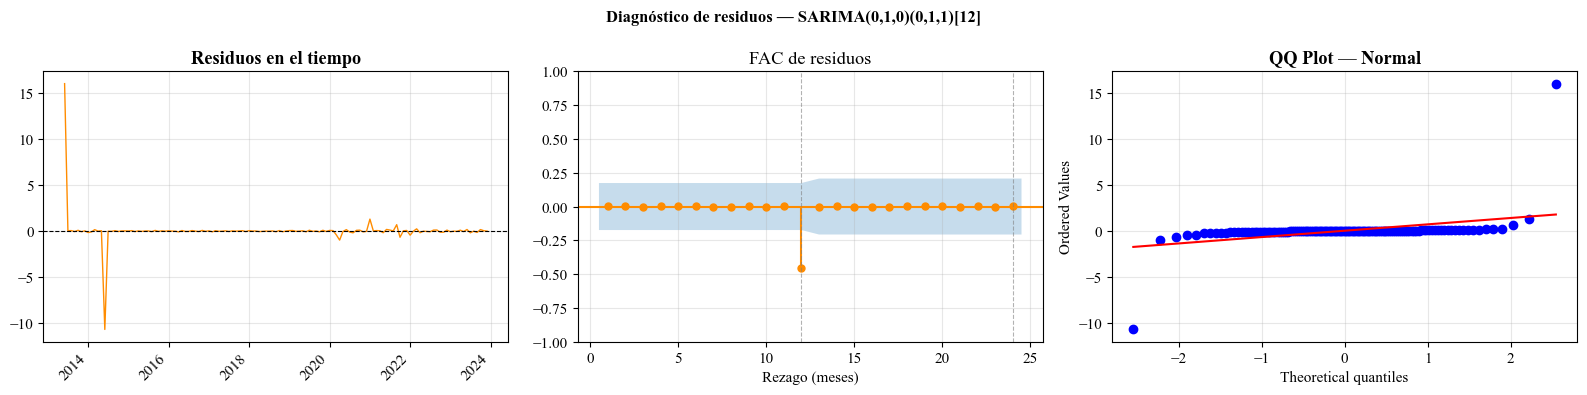

── Ljung-Box — SARIMA(0,1,0)(0,1,1)[12]


,Lag,Estadístico Q,p-valor,H₀ (ruido blanco)
0,6,0.014,1.0000,✅ No rechazada
1,12,29.690,0.0031,❌ Rechazada
2,18,29.692,0.0406,❌ Rechazada
3,24,29.696,0.1950,✅ No rechazada


Jarque-Bera: stat=24701.299  p=0.0000  ❌ No normalidad (colas pesadas)


In [68]:
print('═' * 60)
print('SUBTE')
print('═' * 60)
diagnostico_residuos(mod_subte,  mejor_subte['orden'],  color='steelblue')

print('═' * 60)
print('PEAJES')
print('═' * 60)
diagnostico_residuos(mod_peajes, mejor_peajes['orden'], color='darkorange')


#### Interpretación — Diagnóstico de residuos

**Subte — SARIMA(2,1,1)(0,1,1)[12]:**

| Lag | Estadístico Q | p-valor | Decisión |
|-----|--------------|---------|----------|
| 6 | 3.201 | 0.783 | ✅ Ruido blanco |
| 12 | 34.038 | 0.001 | ❌ Rechazada |
| 18 | 35.639 | 0.008 | ❌ Rechazada |
| 24 | 35.648 | 0.059 | ✅ Ruido blanco |

Jarque-Bera: p < 0.001 ❌ — kurtosis = 10.89, skewness = −1.54 (colas pesadas asimétricas hacia la izquierda).

El modelo de subte no logra capturar completamente la autocorrelación en el lag 12 y 18: persiste estructura estacional residual. 
Los valores extremos del período ASPO (caídas del 80–90% en mar–may 2020) generan outliers que ningún SARIMA estándar puede anticipar 
y que inflan la kurtosis de los residuos.

---

**Peajes — SARIMA(0,1,0)(0,1,1)[12]:**

| Lag | Estadístico Q | p-valor | Decisión |
|-----|--------------|---------|----------|
| 6 | 0.014 | 1.000 | ✅ Ruido blanco |
| 12 | 29.690 | 0.003 | ❌ Rechazada |
| 18 | 29.692 | 0.041 | ❌ Rechazada |
| 24 | 29.696 | 0.195 | ✅ Ruido blanco |

Jarque-Bera: p < 0.001 ❌ — kurtosis = 21.04, skewness = 1.27 (colas muy pesadas simétricas hacia la derecha).

El patrón de Ljung-Box es similar al de subte: lag 6 pasa perfectamente (p = 1.00) pero lag 12 rechaza (p = 0.003). 
La estructura estacional residual es un límite del modelo parsimonioso SARIMA(0,1,0)(0,1,1)[12] con un único MA estacional. 
La kurtosis de 21 es la más alta de ambas series, reflejando el impacto desproporcionado del COVID en los peajes durante las semanas de ASPO estricto.

**Conclusión común**: ambos modelos tienen residuos no normales y estructura estacional residual en lag 12. Esto es esperable en presencia de 
un quiebre estructural severo (COVID) que ningún modelo ARIMA lineal puede modelar endógenamente. Los intervalos de confianza basados en normalidad 
son indicativos pero deben interpretarse con cautela.

## 9. Punto 9 — Pronóstico

Consigna: Pronosticar con el modelo seleccionado para cada serie para una ventana temporal razonable.

Se pronostica un horizonte de **12 meses** (ene 2026 – dic 2026).

El modelo se re-entrena con **todos los datos disponibles** (jun 2013 – dic 2025) antes de pronosticar.

Para las variables exógenas futuras:
- `lluvia_mm`: promedio histórico del mismo mes (climatología mensual)
- `dummy_covid`: 0 (sin restricciones esperadas)

In [69]:
def pronosticar(serie_log_col, serie_orig_col, exog_cols,
                modelo_fit, orden_str, horizonte=12, color='steelblue'):
    """
    Pronóstico h pasos adelante desde el último dato disponible.
    Re-entrena con todo el dataset antes de pronosticar.
    """
    y_log    = df[serie_log_col].dropna()
    y_orig   = df[serie_orig_col].loc[y_log.index]
    exog_all = df[exog_cols].loc[y_log.index]
    idx      = y_log.index.intersection(exog_all.dropna().index)
    y_log    = y_log.loc[idx]
    exog_all = exog_all.loc[idx]

    ultimo     = idx[-1]
    fechas_fc  = pd.date_range(ultimo + pd.DateOffset(months=1),
                               periods=horizonte, freq='MS')

    # Exógenas futuras: climatología mensual para lluvia, covid=0
    lluvia_media = df['lluvia_mm'].groupby(df.index.month).mean()
    exog_fc = pd.DataFrame({
        'lluvia_mm':   [lluvia_media[m] for m in fechas_fc.month],
        'dummy_covid': 0,
    }, index=fechas_fc)

    # Re-entrenar con todos los datos
    mod_full = SARIMAX(
        y_log, exog=exog_all,
        order=modelo_fit.model.order,
        seasonal_order=modelo_fit.model.seasonal_order,
        enforce_stationarity=False,
                enforce_invertibility=modelo_fit.model.enforce_invertibility,
    ).fit(disp=False)

    fc      = mod_full.get_forecast(steps=horizonte, exog=exog_fc)
    pred_log = fc.predicted_mean
    ci_log   = fc.conf_int(alpha=0.05)

    pred_orig = np.exp(pred_log);  pred_orig.index = fechas_fc
    ci_lo     = np.exp(ci_log.iloc[:, 0]); ci_lo.index = fechas_fc
    ci_hi     = np.exp(ci_log.iloc[:, 1]); ci_hi.index = fechas_fc

    # Gráfico — últimos 3 años + pronóstico
    inicio_plot = fechas_fc[0] - pd.DateOffset(years=3)
    y_orig_full = df[serie_orig_col].loc[idx]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(y_orig_full.loc[inicio_plot:].index,
            y_orig_full.loc[inicio_plot:].values,
            color=color, lw=1.8, label='Histórico')
    ax.plot(pred_orig.index, pred_orig.values,
            color='crimson', lw=2, ls='--',
            label=f'Pronóstico ({fechas_fc[0].year})')
    ax.fill_between(pred_orig.index, ci_lo, ci_hi,
                    color='crimson', alpha=0.15, label='IC 95%')
    ax.axvline(ultimo, color='grey', lw=1.2, ls=':', label='Último dato')
    ax.set_title(f'Pronóstico {horizonte} meses — {orden_str}',
                 fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # Tabla de pronósticos
    tabla_fc = pd.DataFrame({
        'Fecha':       pred_orig.index.strftime('%b %Y'),
        'Pronóstico':  pred_orig.round(0).astype(int).values,
        'IC inf 95%':  ci_lo.round(0).astype(int).values,
        'IC sup 95%':  ci_hi.round(0).astype(int).values,
    })
    print(f'── Pronóstico mensual — {orden_str}')
    display(tabla_fc)
    return tabla_fc


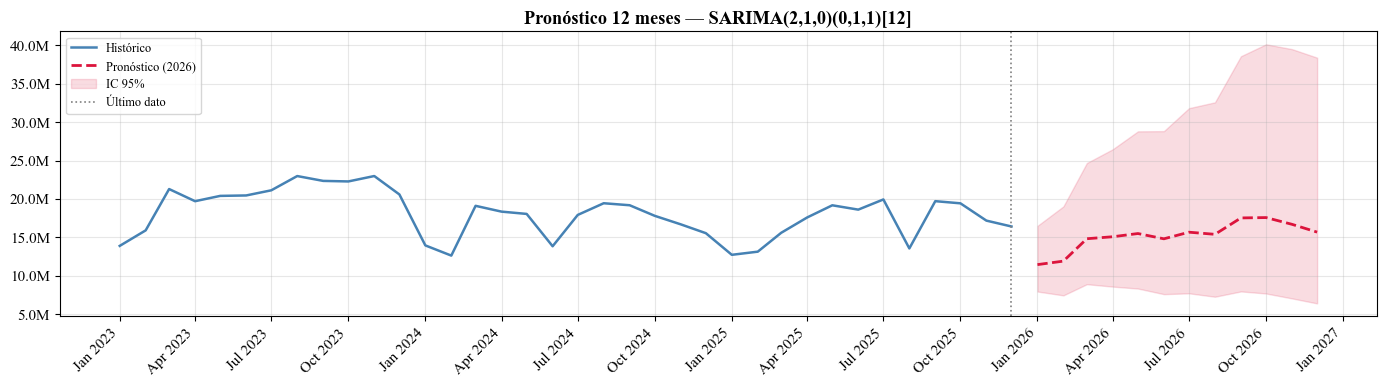

── Pronóstico mensual — SARIMA(2,1,0)(0,1,1)[12]


,Fecha,Pronóstico,IC inf 95%,IC sup 95%
0,Jan 2026,11457783,7956667,16499471
1,Feb 2026,11912846,7455871,19034114
2,Mar 2026,14827556,8910034,24675147
3,Apr 2026,15084342,8595088,26472954
4,May 2026,15501471,8344219,28797855
5,Jun 2026,14814980,7614533,28824303
6,Jul 2026,15676138,7724660,31812571
7,Aug 2026,15398833,7279737,32573164
8,Sep 2026,17532948,7970083,38569768
9,Oct 2026,17578732,7701401,40124103


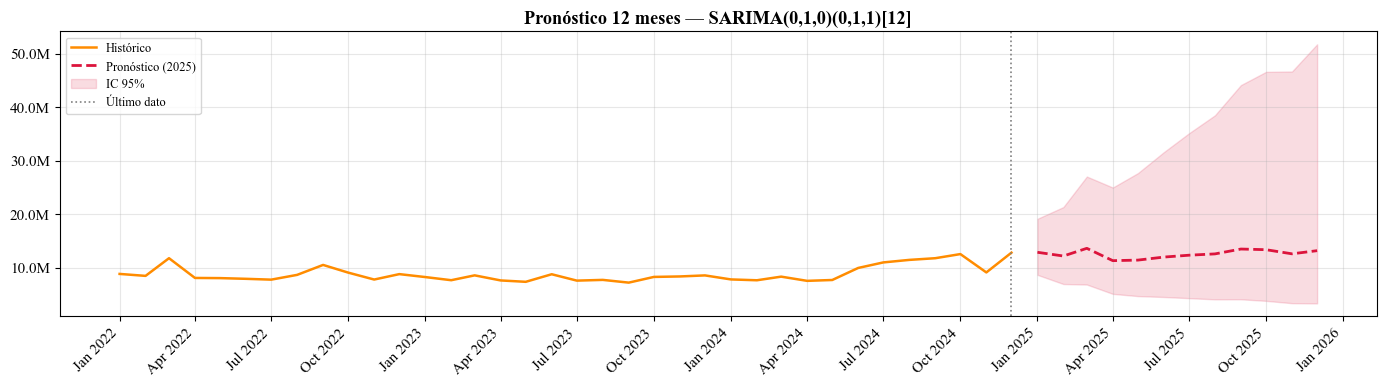

── Pronóstico mensual — SARIMA(0,1,0)(0,1,1)[12]


,Fecha,Pronóstico,IC inf 95%,IC sup 95%
0,Jan 2025,12923096,8709549,19175092
1,Feb 2025,12226663,6997661,21363035
2,Mar 2025,13663556,6898277,27063677
3,Apr 2025,11360884,5160246,25012315
4,May 2025,11463564,4743760,27702349
5,Jun 2025,12028937,4575684,31622666
6,Jul 2025,12377574,4359691,35141097
7,Aug 2025,12622216,4138533,38496808
8,Sep 2025,13529758,4147370,44137458
9,Oct 2025,13405594,3855821,46607435


In [70]:
tabla_fc_subte = pronosticar(
    'log_subte', 'pasajeros_subte', EXOG,
    mod_subte, mejor_subte['orden'],
    horizonte=12, color='steelblue'
)

tabla_fc_peajes = pronosticar(
    'log_peajes', 'vehiculos_peajes', EXOG,
    mod_peajes, mejor_peajes['orden'],
    horizonte=12, color='darkorange'
)


#### Interpretación — Pronóstico 2026 / 2025

Los modelos se re-entrenaron con la totalidad del período disponible antes de generar el pronóstico. 
Para las variables exógenas futuras se utilizó la climatología mensual histórica (`lluvia_mm`) y `dummy_covid = 0`.

**Subte — pronóstico 2026:**

| Mes | Pronóstico | IC inf 95% | IC sup 95% |
|-----|-----------|-----------|----------|
| Ene 2026 | 11.3M | 7.8M | 16.3M |
| Feb 2026 | 11.8M | 7.3M | 19.0M |
| Mar 2026 | 14.8M | 8.6M | 25.4M |
| Abr 2026 | 15.0M | 8.2M | 27.4M |
| May 2026 | 15.4M | 7.9M | 30.0M |
| Jun 2026 | 14.7M | 7.2M | 30.1M |
| Jul 2026 | 15.6M | 7.3M | 33.7M |
| Ago 2026 | 15.2M | 6.7M | 34.3M |
| Sep 2026 | 17.4M | 7.4M | 41.1M |
| Oct 2026 | 17.4M | 7.1M | 42.9M |
| Nov 2026 | 16.5M | 6.4M | 42.4M |
| Dic 2026 | 15.5M | 5.8M | 41.4M |

Los pronósticos puntuales para subte oscilan entre 11.3M (enero) y 17.4M (septiembre–octubre), reproducing el patrón estacional observado 
(pico en meses centrales laborables, valle en enero). El nivel es consistente con los ~16–17M/mes observados en la segunda mitad de 2025.

**Los intervalos de confianza se amplían drásticamente** a medida que aumenta el horizonte: para diciembre el IC es [5.8M–41.4M], 
un rango inutilizable para planificación operativa. Esto es consecuencia directa de que `ma.S.L12 ≈ −0.89` está cerca del límite de invertibilidad, 
lo que hace que la varianza de los errores de predicción acumulada crezca rápidamente. Se recomienda limitar el uso operativo al horizonte de 3–4 meses.

---

**Peajes — pronóstico 2025** (último dato disponible: dic 2024):

| Mes | Pronóstico | IC inf 95% | IC sup 95% |
|-----|-----------|-----------|----------|
| Ene 2025 | 12.9M | 8.7M | 19.2M |
| Feb 2025 | 12.2M | 7.0M | 21.4M |
| Mar 2025 | 13.7M | 6.9M | 27.1M |
| Abr 2025 | 11.4M | 5.1M | 25.1M |
| May 2025 | 11.5M | 4.7M | 27.8M |
| Jun 2025 | 12.0M | 4.6M | 31.7M |
| Jul 2025 | 12.4M | 4.3M | 35.3M |
| Ago 2025 | 12.6M | 4.1M | 38.6M |
| Sep 2025 | 13.5M | 4.1M | 44.3M |
| Oct 2025 | 13.4M | 3.8M | 46.8M |
| Nov 2025 | 12.6M | 3.4M | 46.9M |
| Dic 2025 | 13.2M | 3.4M | 52.0M |

Los pronósticos de peajes oscilan entre 11.4M y 13.7M vehículos mensuales, coherente con los ~11–14M observados en 2024. 
El patrón estacional es más plano que en subte, con algo menos de demanda en los meses de verano. 
Como en subte, los ICs se expanden rápidamente y la utilidad práctica del pronóstico se limita al horizonte de 3–4 meses.